In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


/kaggle/input/train.csv
/kaggle/input/description.md
/kaggle/input/sample_submission.csv.zip
/kaggle/input/test.csv.zip
/kaggle/input/train.csv.zip
/kaggle/input/test.csv
/kaggle/input/sample_submission.csv
/kaggle/input/playground-series-s3e18/train.csv
/kaggle/input/playground-series-s3e18/description.md
/kaggle/input/playground-series-s3e18/sample_submission.csv.zip
/kaggle/input/playground-series-s3e18/test.csv.zip
/kaggle/input/playground-series-s3e18/train.csv.zip
/kaggle/input/playground-series-s3e18/test.csv
/kaggle/input/playground-series-s3e18/sample_submission.csv


In [2]:
from matplotlib import pyplot as plt 
import seaborn as sns

from scipy import stats
from scipy.stats import norm, skew, boxcox
from collections import Counter
!pip install sweetviz


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 60.0 MB/s eta 0:00:00


In [3]:
sumbission = pd.read_csv("/kaggle/input/playground-series-s3e18/sample_submission.csv")
train = pd.read_csv("/kaggle/input/playground-series-s3e18/train.csv")
test = pd.read_csv("/kaggle/input/playground-series-s3e18/test.csv")


In [4]:
train.head()


,id,BertzCT,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3v,Chi4n,EState_VSA1,...,SlogP_VSA3,VSA_EState9,fr_COO,fr_COO2,EC1,EC2,EC3,EC4,EC5,EC6
0,3305,212.928441,6.270857,3.431698,4.045502,1.811731,2.272429,1.619489,0.828835,7.822697,...,13.825658,36.819857,0,0,1,1,0,1,0,0
1,8217,221.694355,4.060660,3.548618,3.548618,2.499652,2.499652,1.607504,0.883813,17.980451,...,9.589074,39.833333,2,2,1,0,0,1,0,0
2,12616,159.130752,4.414719,2.801636,2.801636,2.676274,2.676274,1.204209,0.361282,12.011146,...,11.215359,33.500000,1,1,1,1,0,0,0,0
3,10153,1239.282494,16.098662,10.151117,10.151117,11.008637,11.008637,7.914542,3.408511,5.969305,...,9.589074,73.500000,1,1,1,1,0,0,0,0
4,9564,574.170559,8.417121,5.143525,5.143525,3.478542,3.478542,2.264463,2.087653,5.969305,...,4.794537,39.166667,1,1,1,0,0,1,0,0


In [5]:
train.dtypes


id                     int64
BertzCT              float64
Chi1                 float64
Chi1n                float64
Chi1v                float64
Chi2n                float64
Chi2v                float64
Chi3v                float64
Chi4n                float64
EState_VSA1          float64
EState_VSA2          float64
ExactMolWt           float64
FpDensityMorgan1     float64
FpDensityMorgan2     float64
FpDensityMorgan3     float64
HallKierAlpha        float64
HeavyAtomMolWt       float64
Kappa3               float64
MaxAbsEStateIndex    float64
MinEStateIndex       float64
NumHeteroatoms         int64
PEOE_VSA10           float64
PEOE_VSA14           float64
PEOE_VSA6            float64
PEOE_VSA7            float64
PEOE_VSA8            float64
SMR_VSA10            float64
SMR_VSA5             float64
SlogP_VSA3           float64
VSA_EState9          float64
fr_COO                 int64
fr_COO2                int64
EC1                    int64
EC2                    int64
EC3           

In [6]:
import sweetviz as sv

my_report = sv.analyze(train)
my_report.show_html() # Default arguments will generate to "SWEETVIZ_REPORT.html"


                                             |          | [  0%]   00:00 -> (? left)

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.



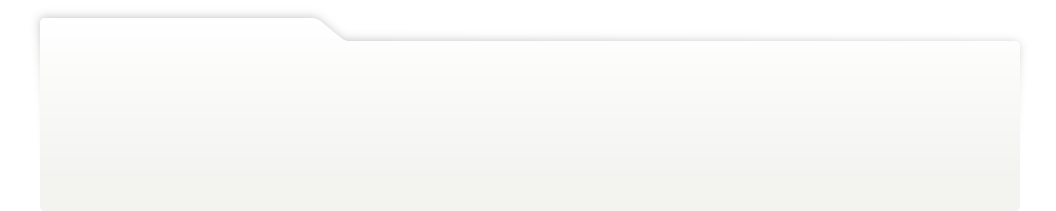
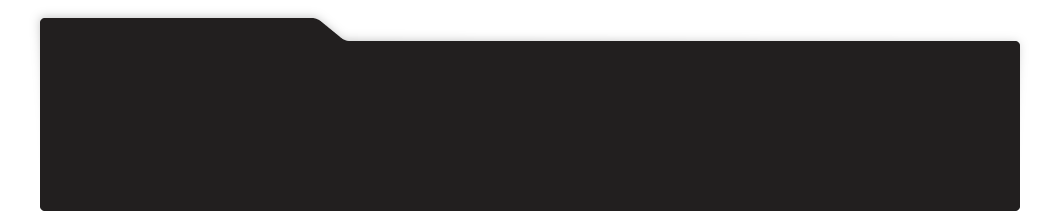
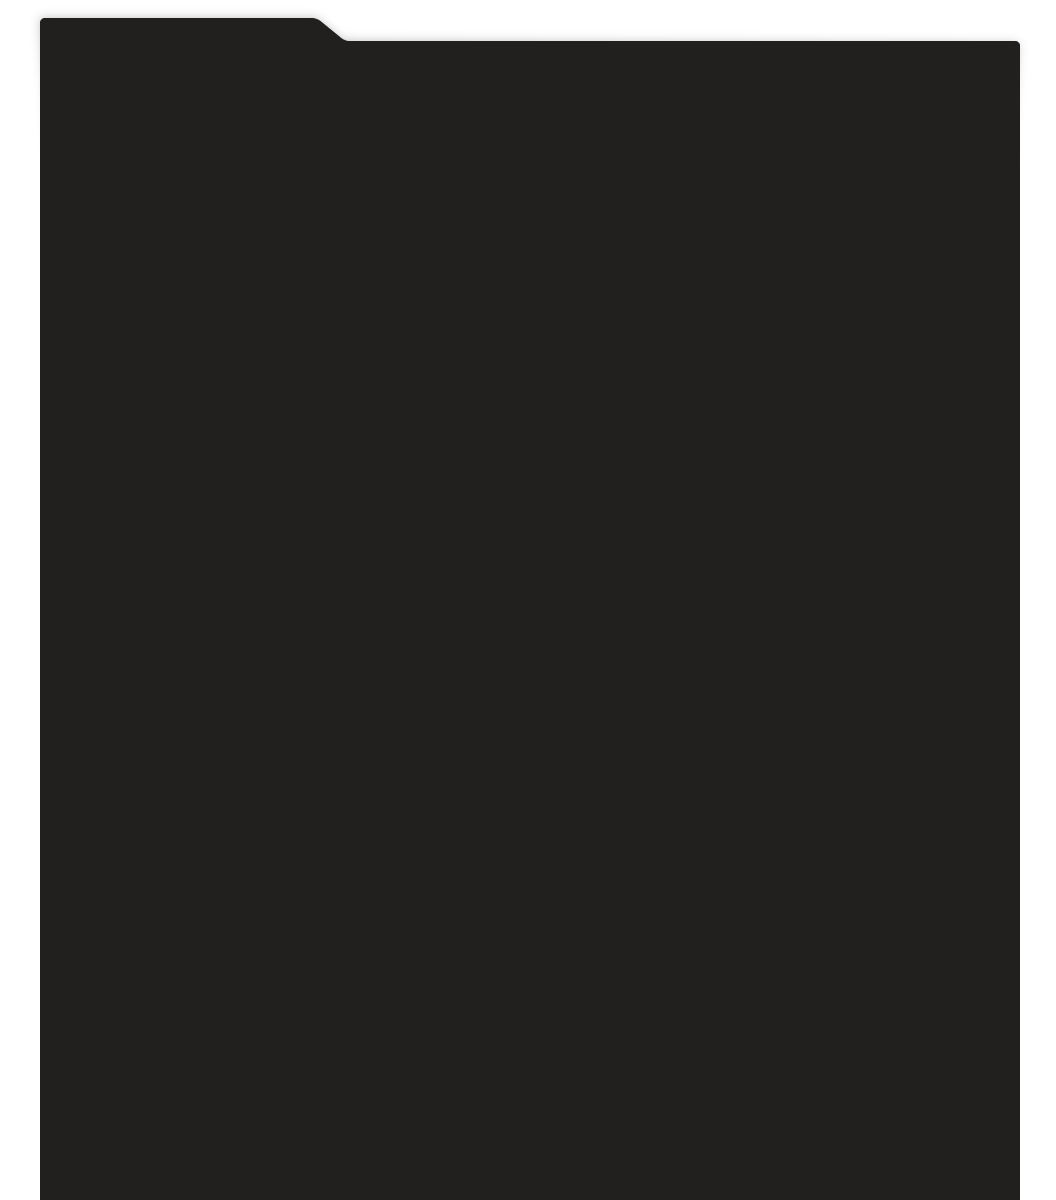
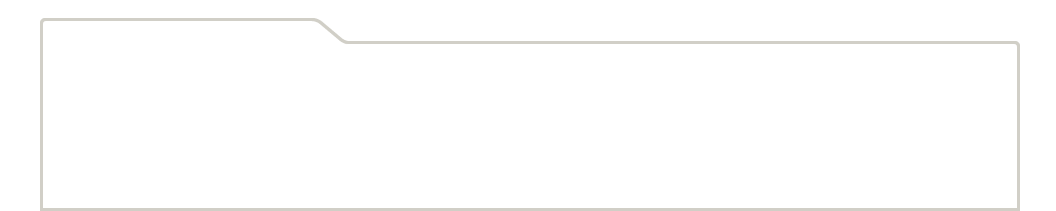
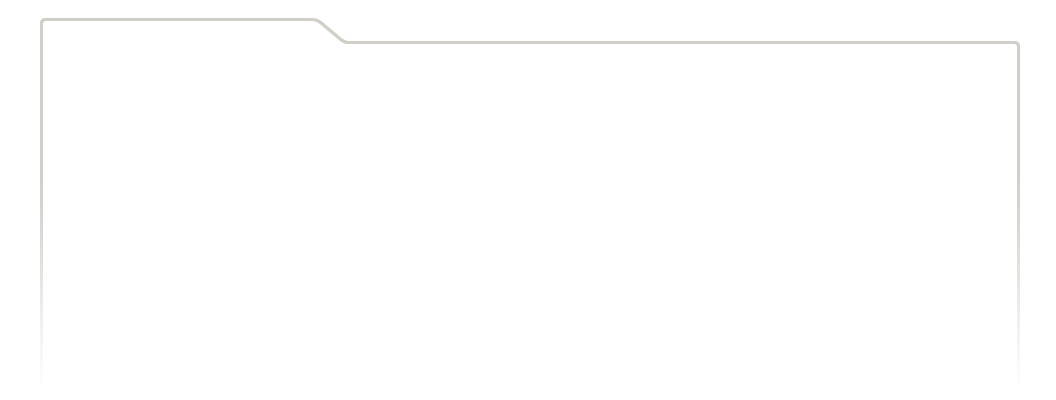
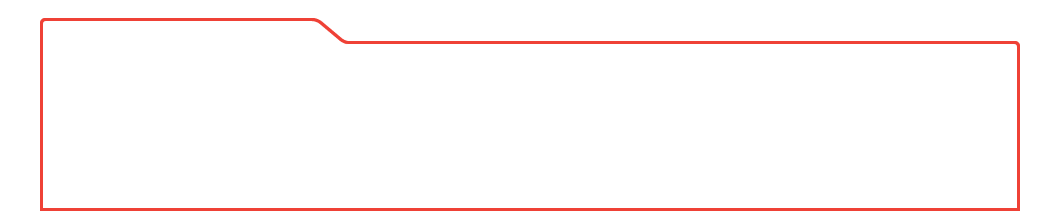
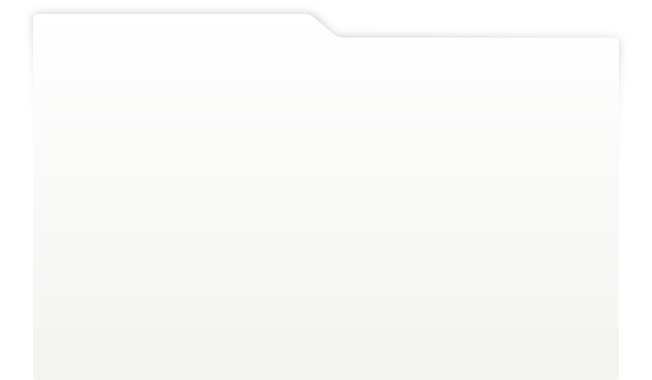
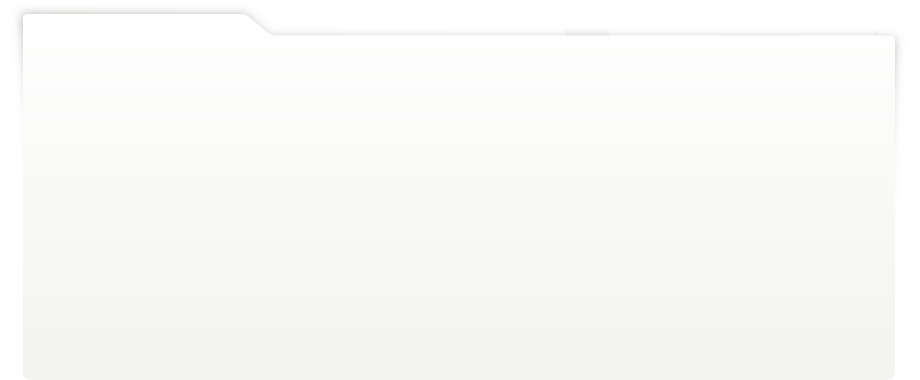
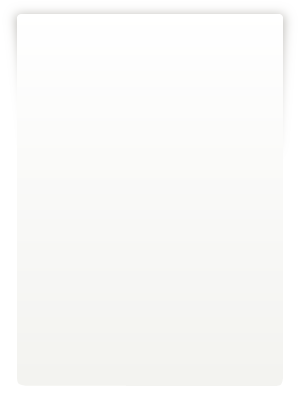
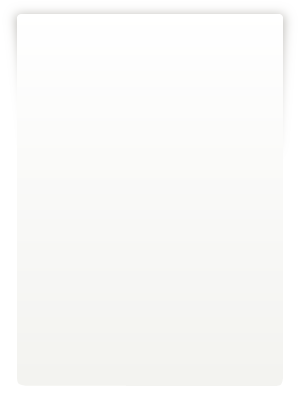
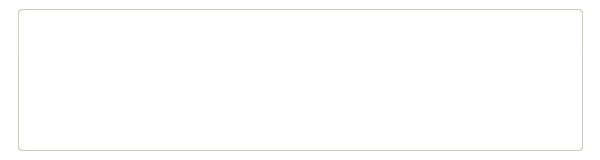
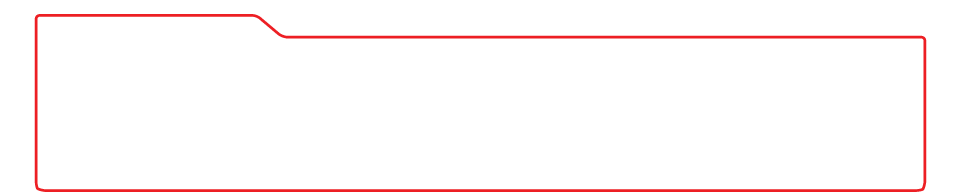
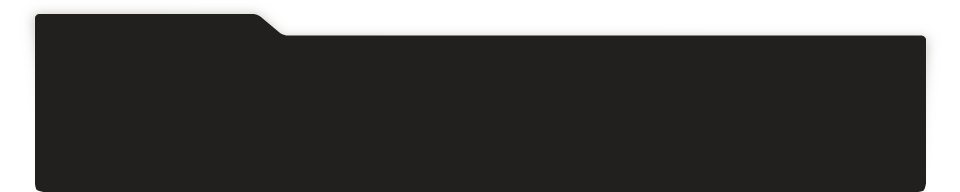
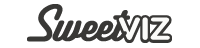
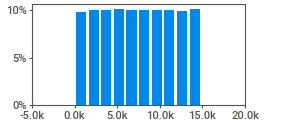
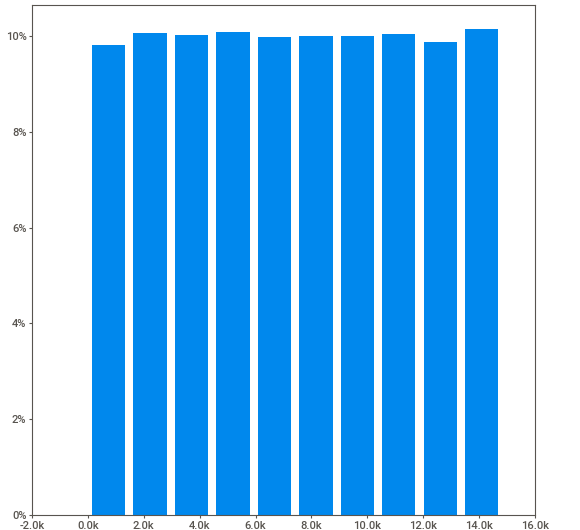
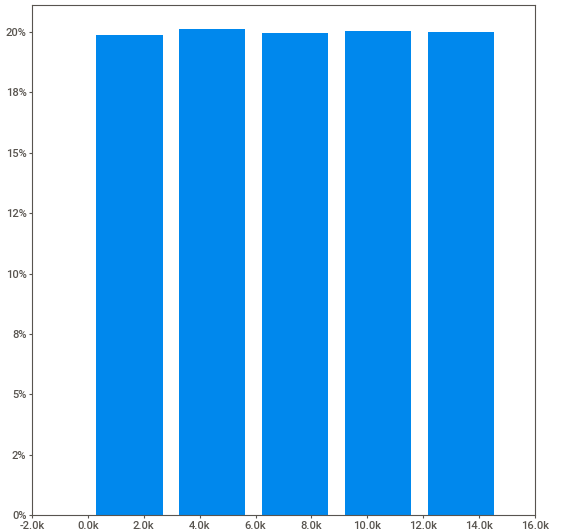
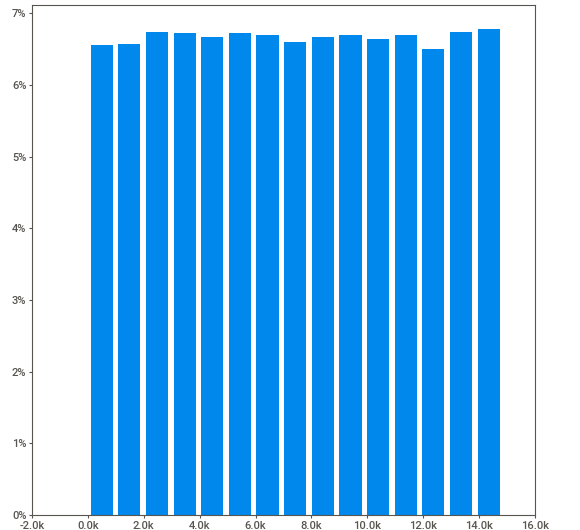
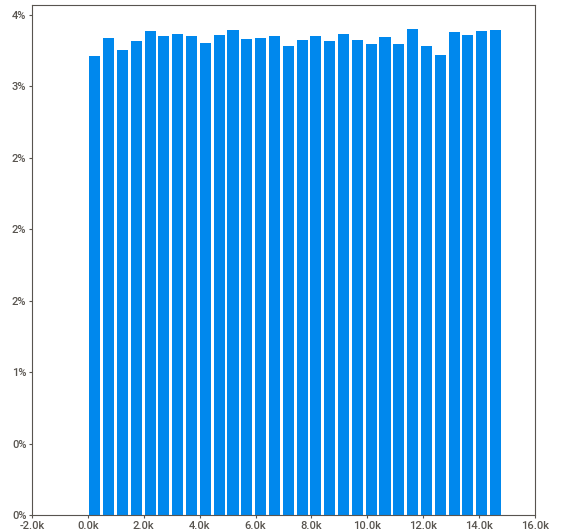
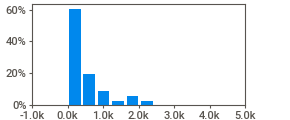
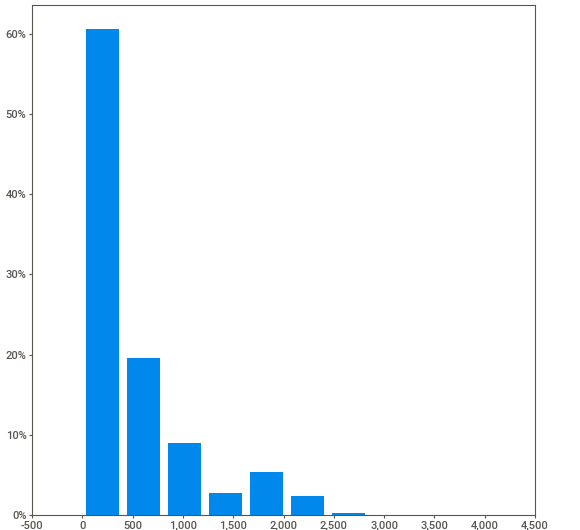
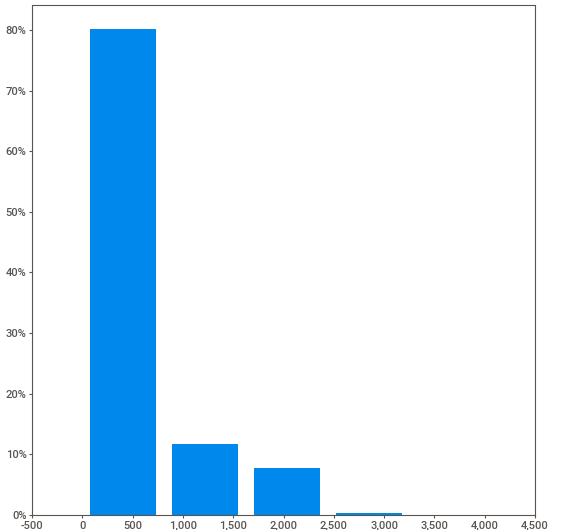
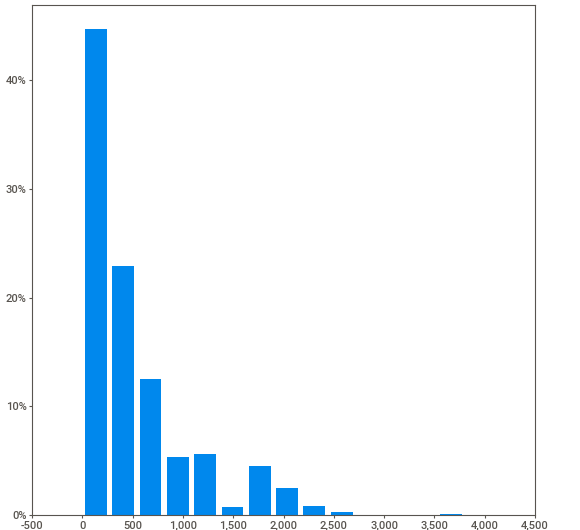
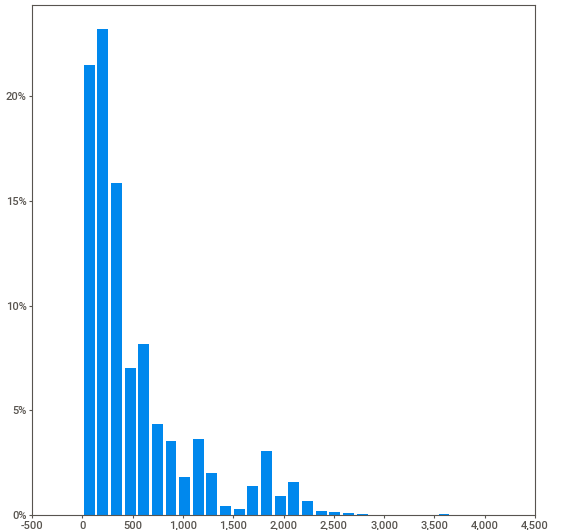
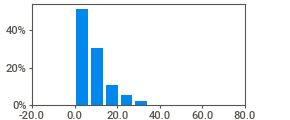
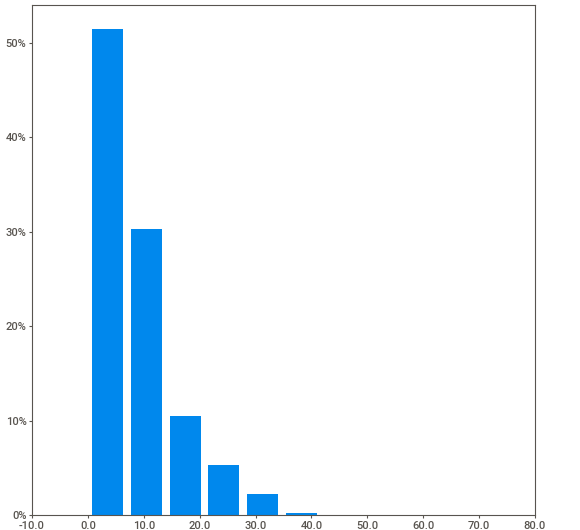
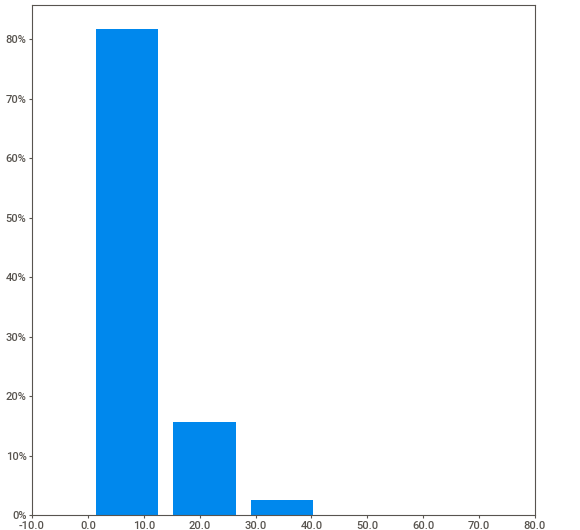
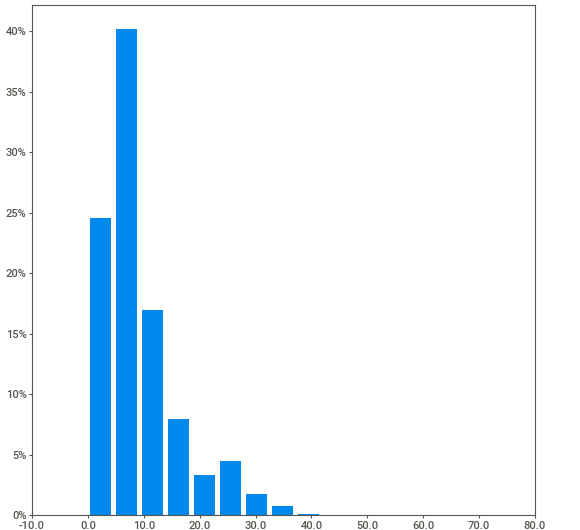
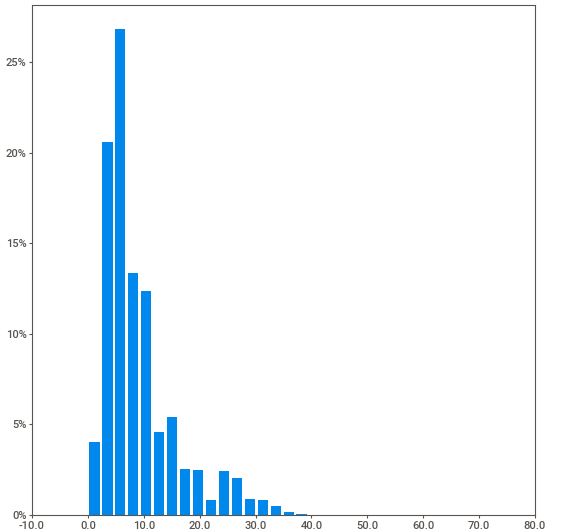
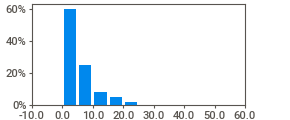
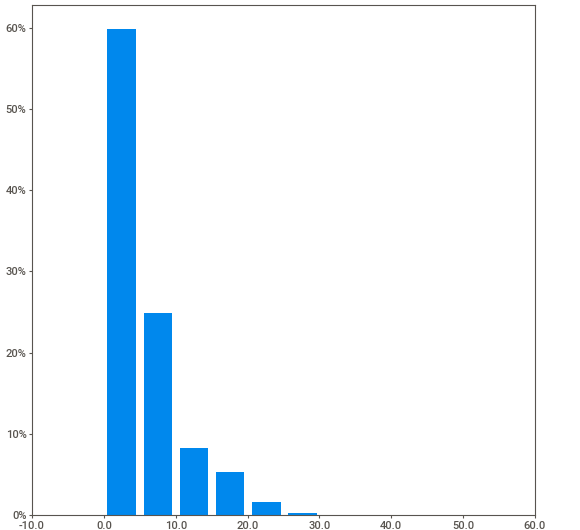
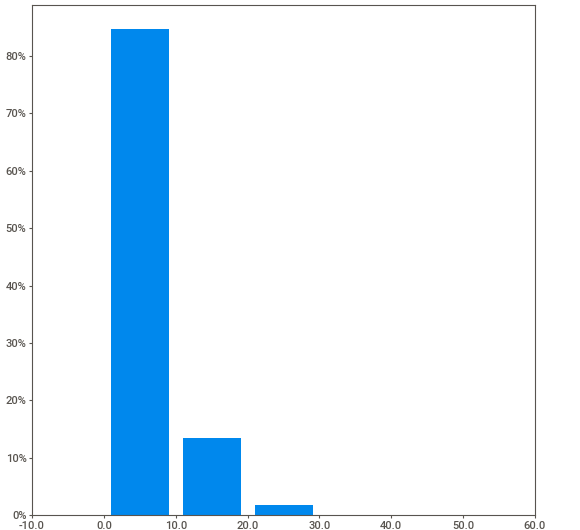
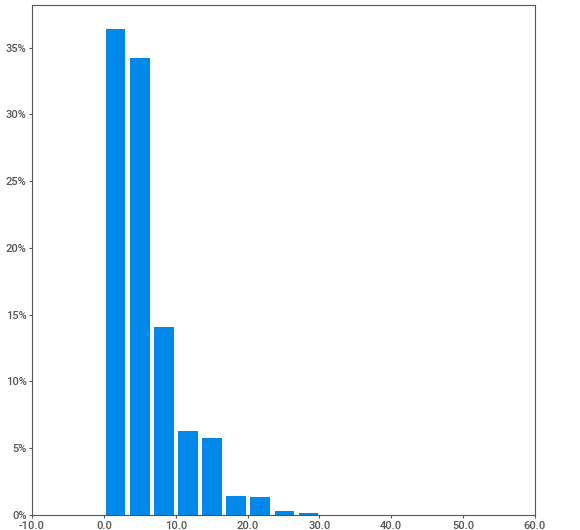
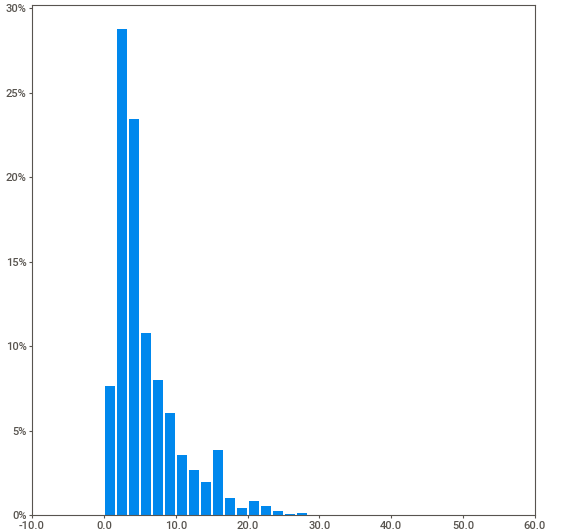
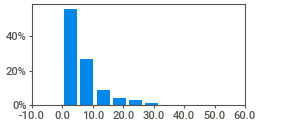
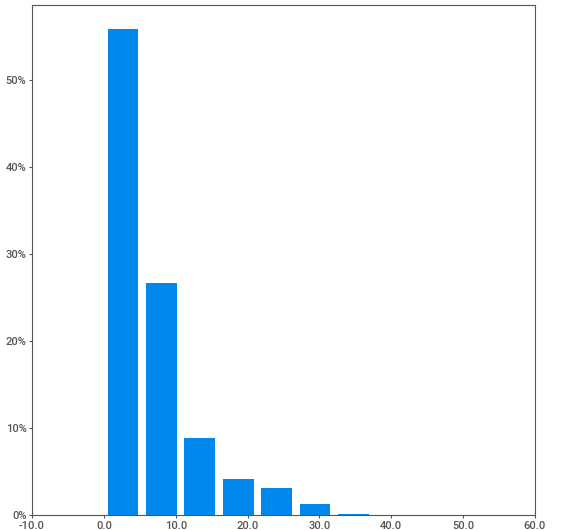
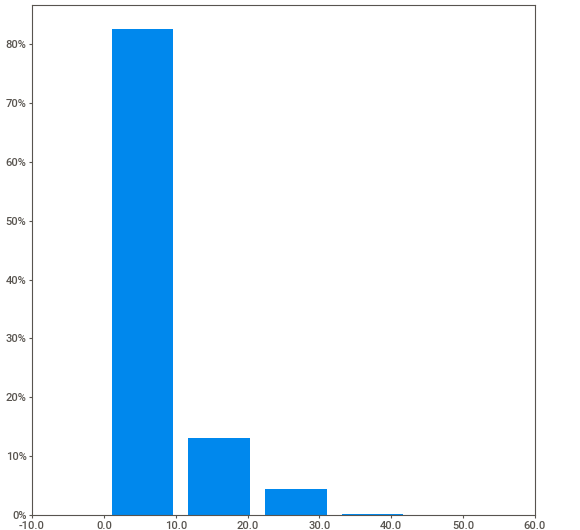
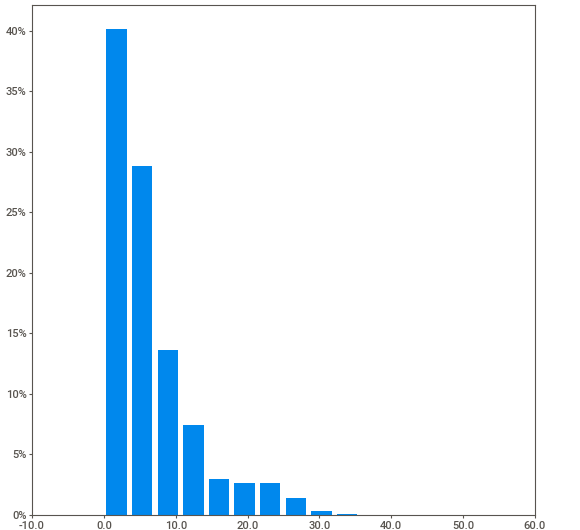
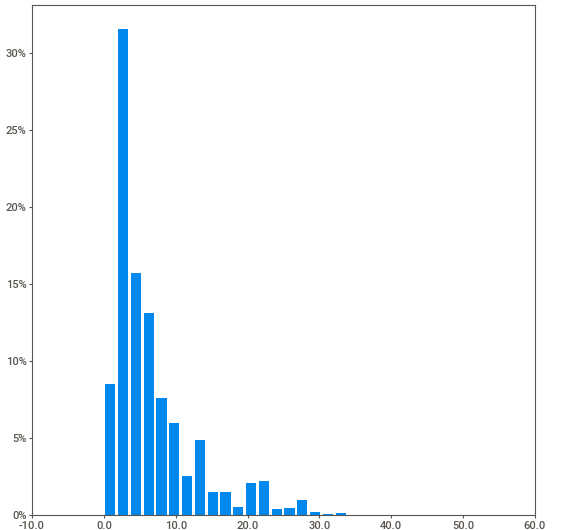
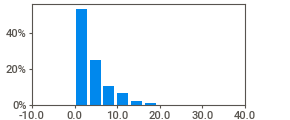
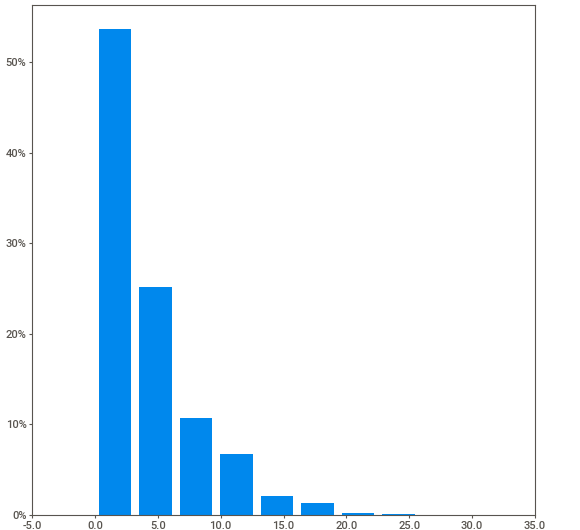
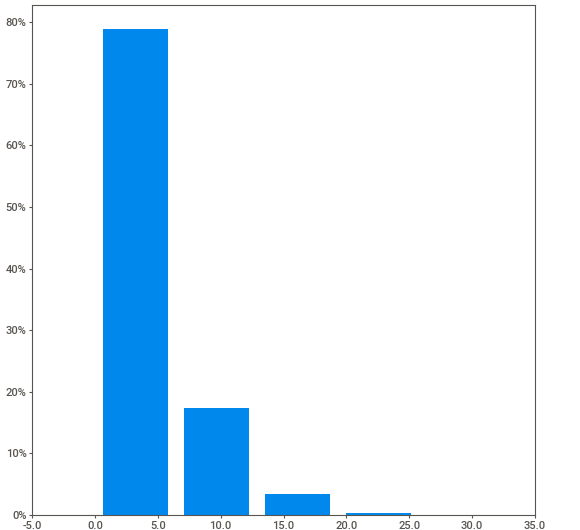
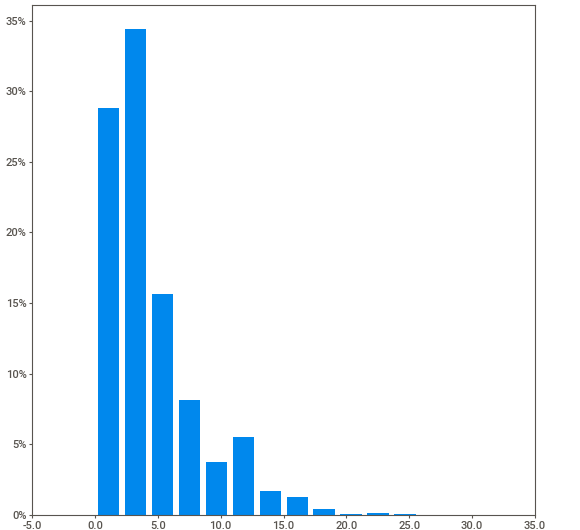
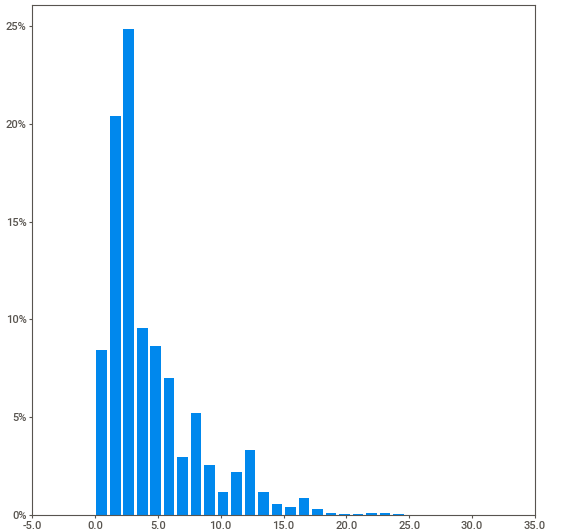
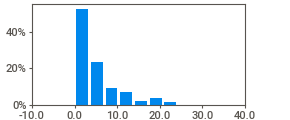
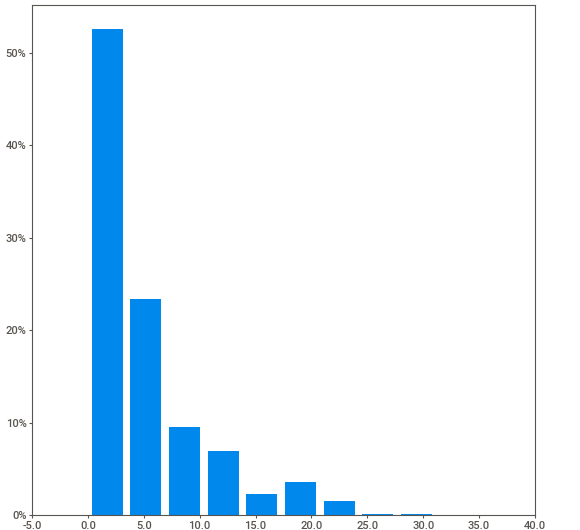
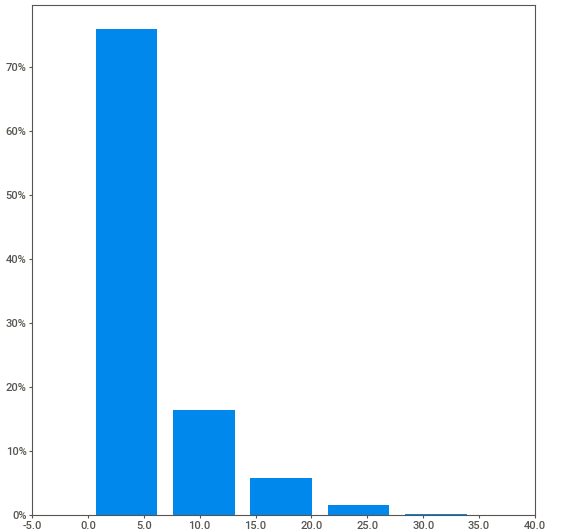
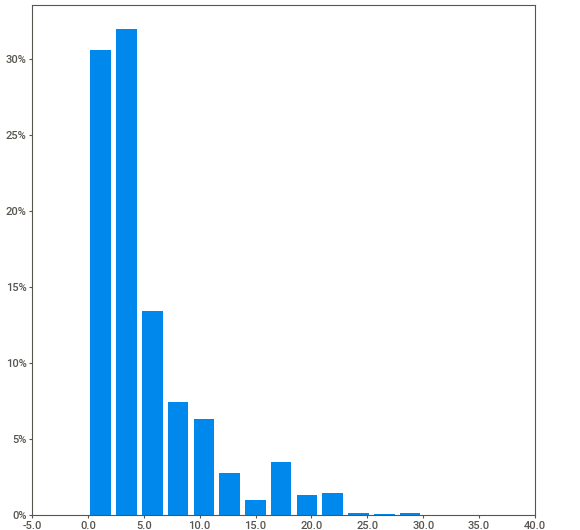
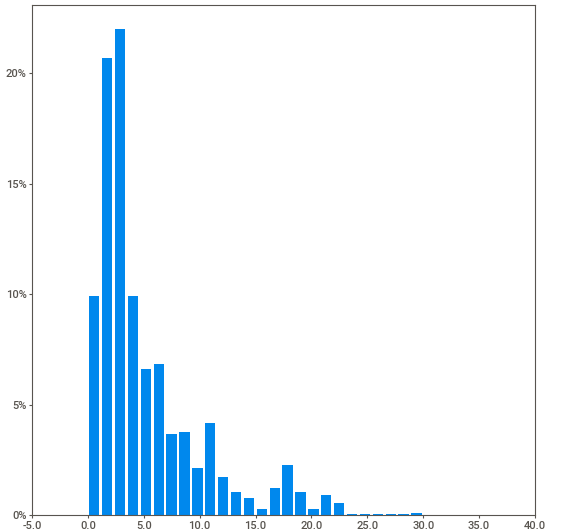
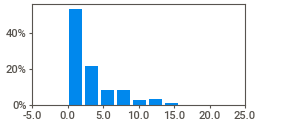
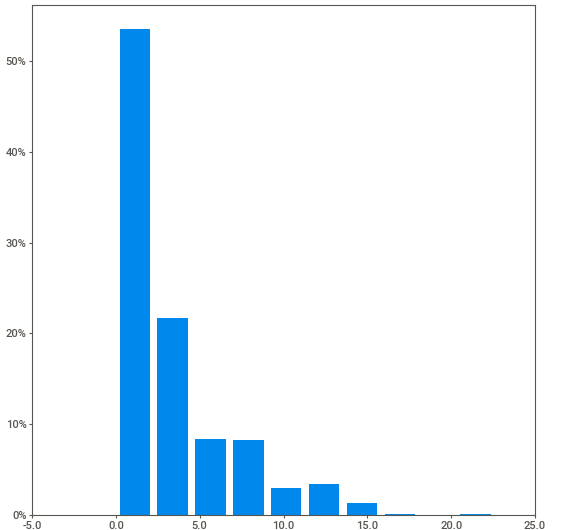
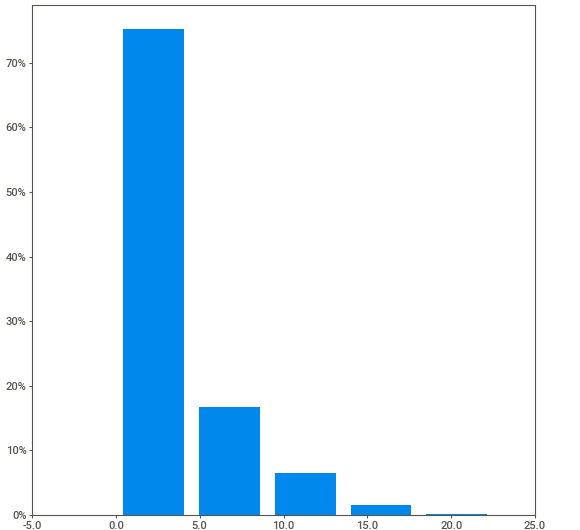
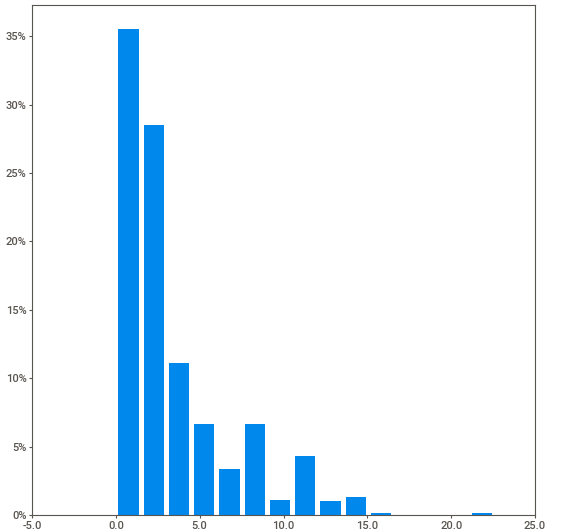
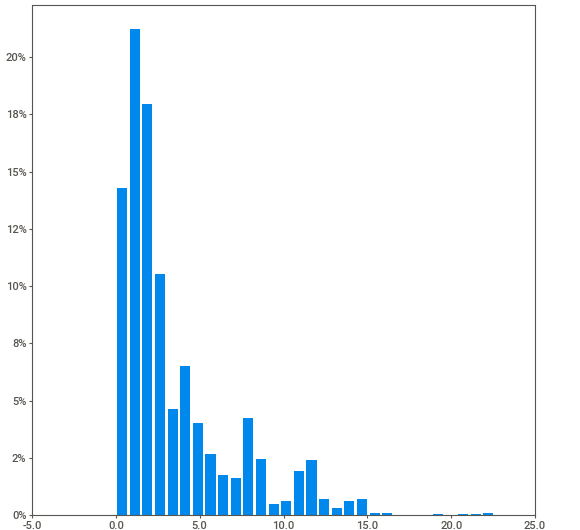
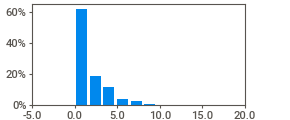
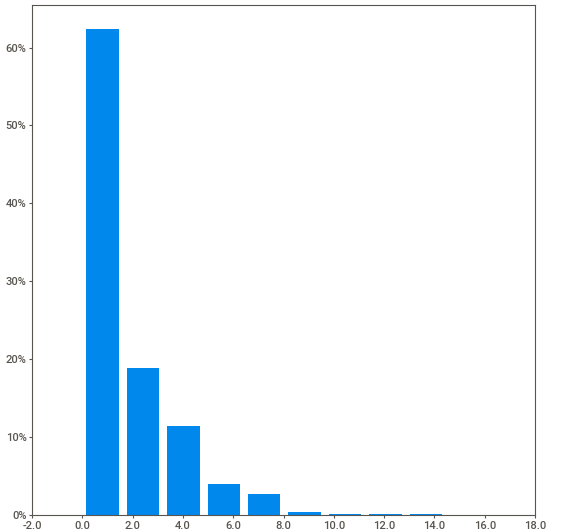
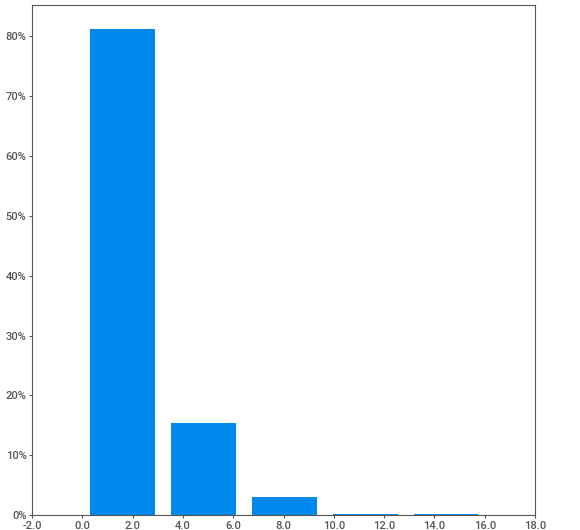
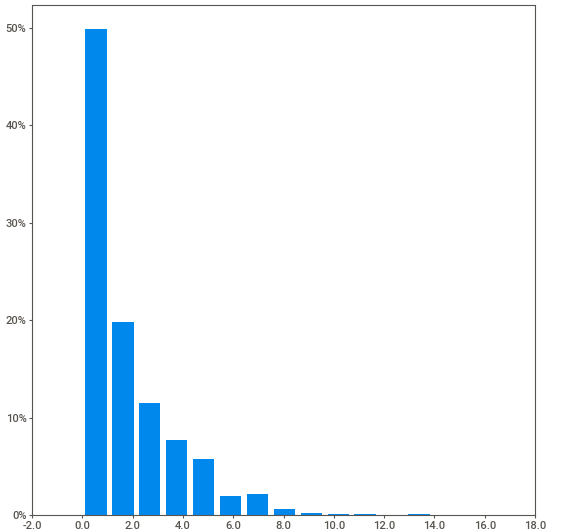
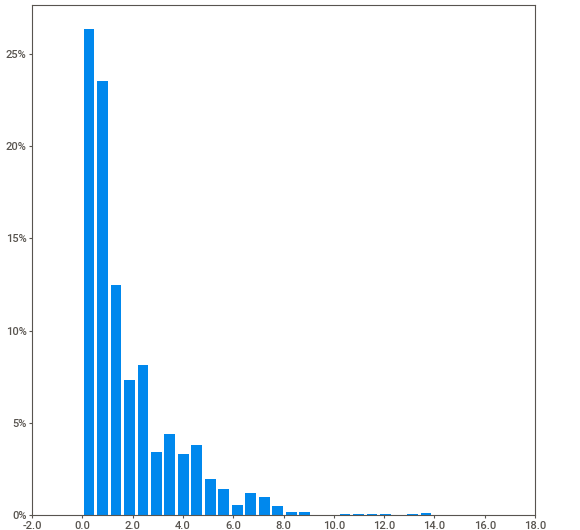
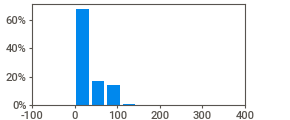
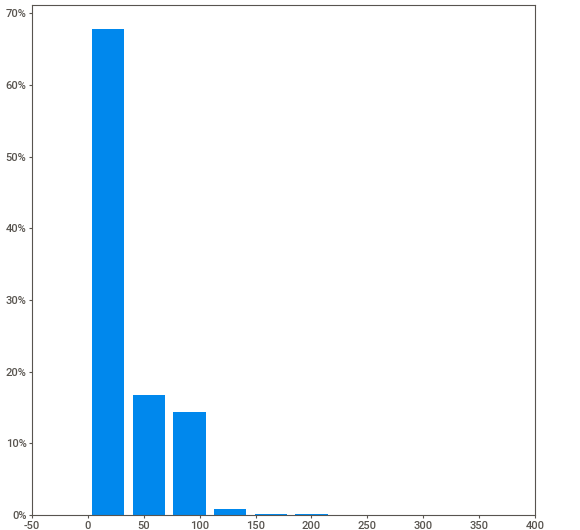
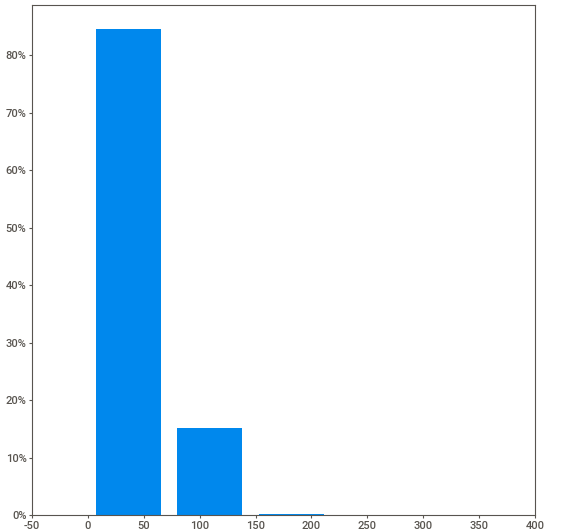
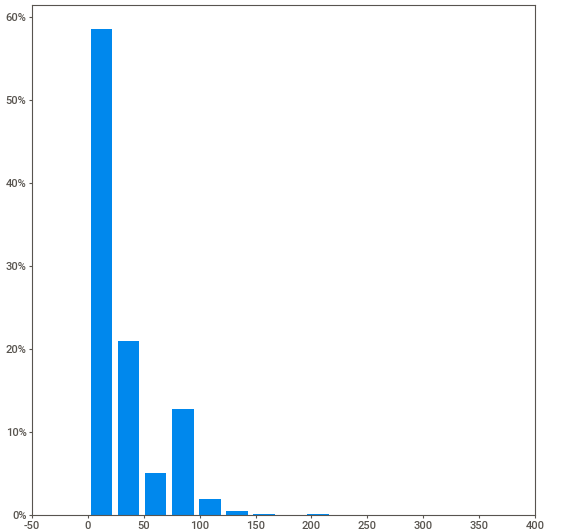
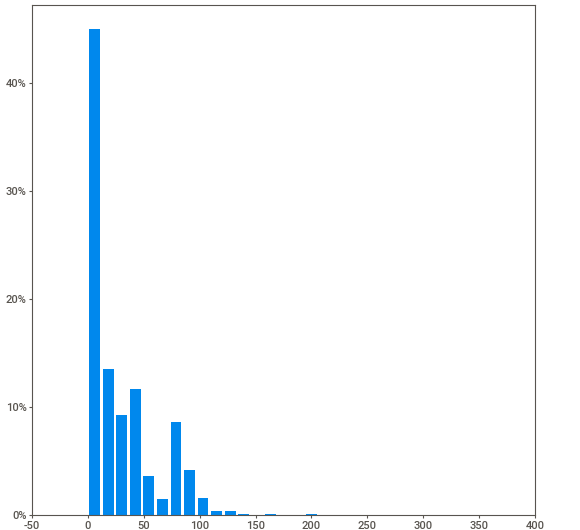
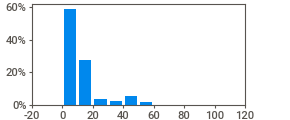
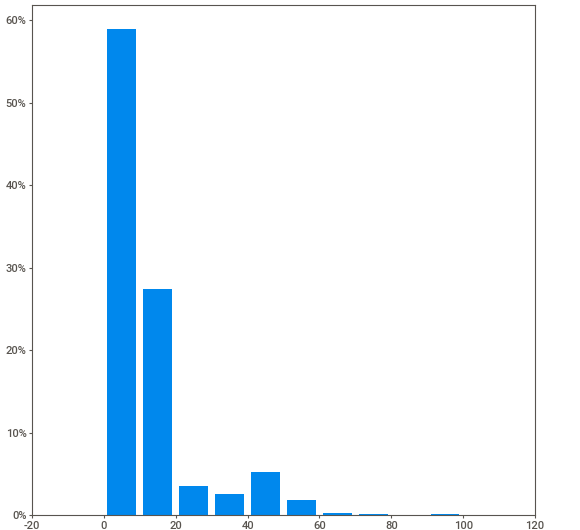
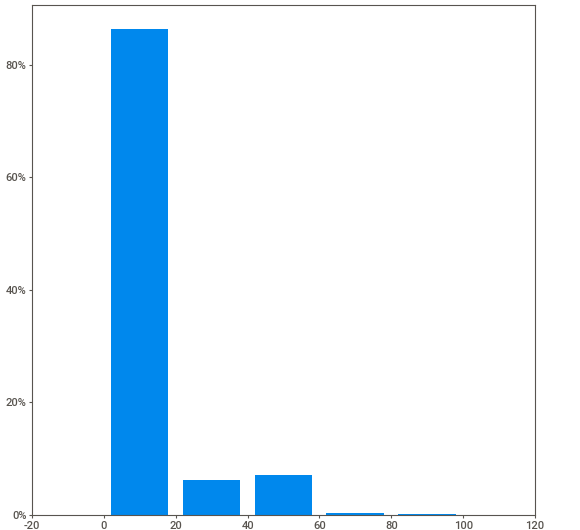
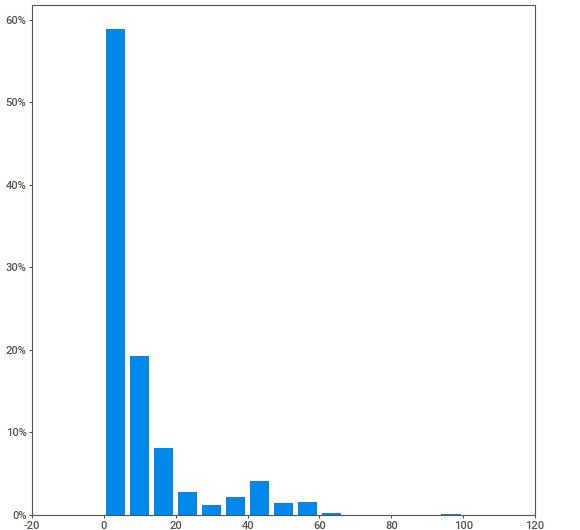
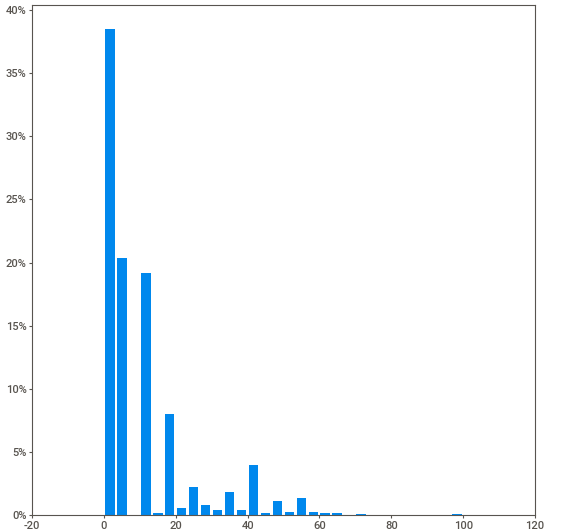
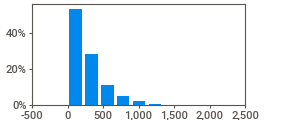
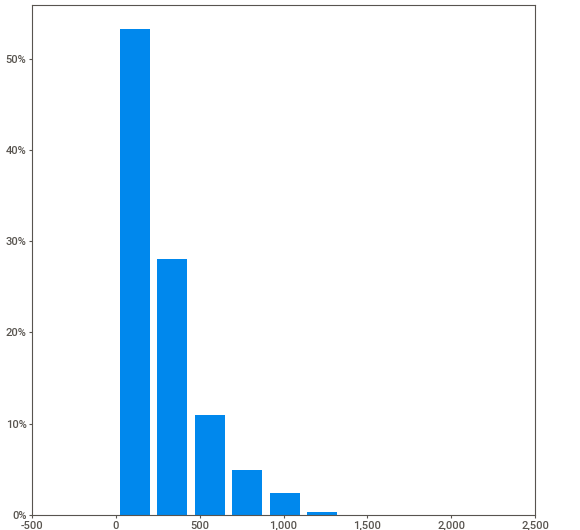
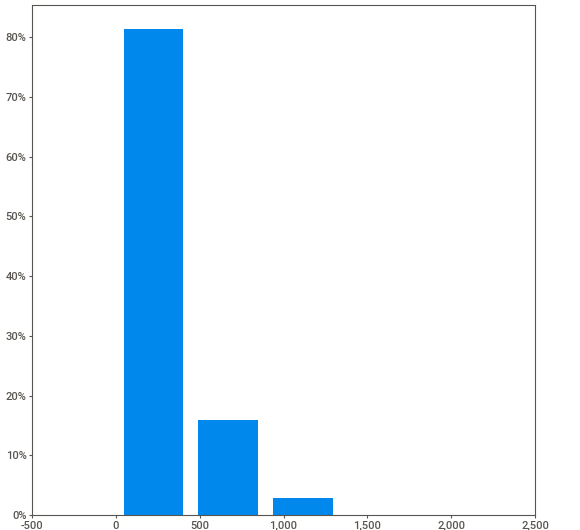
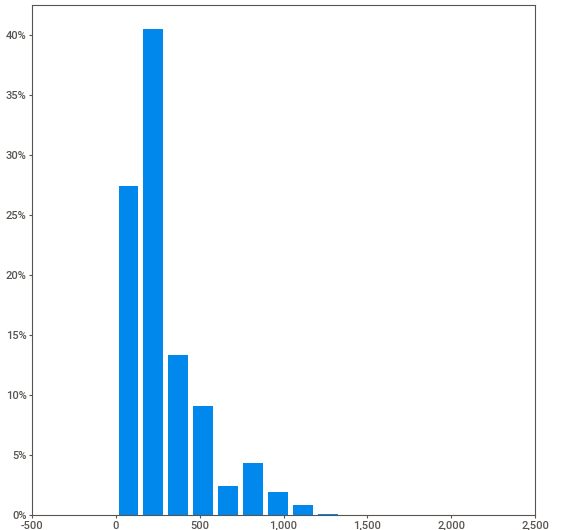
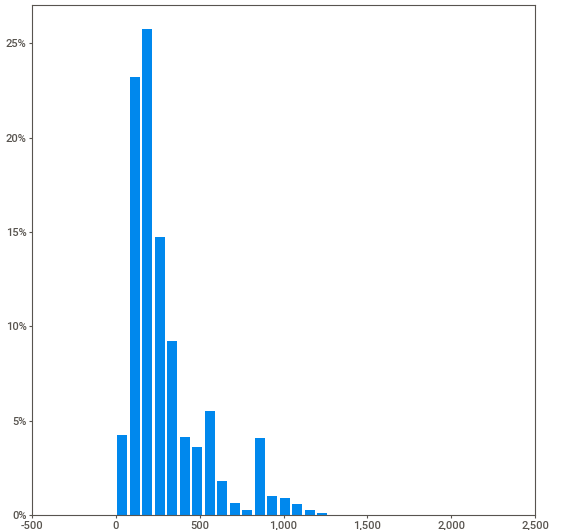
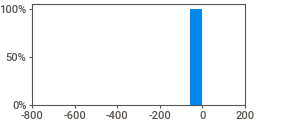
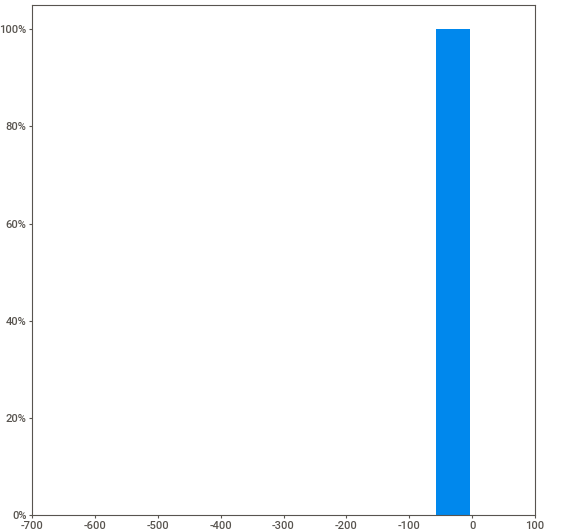
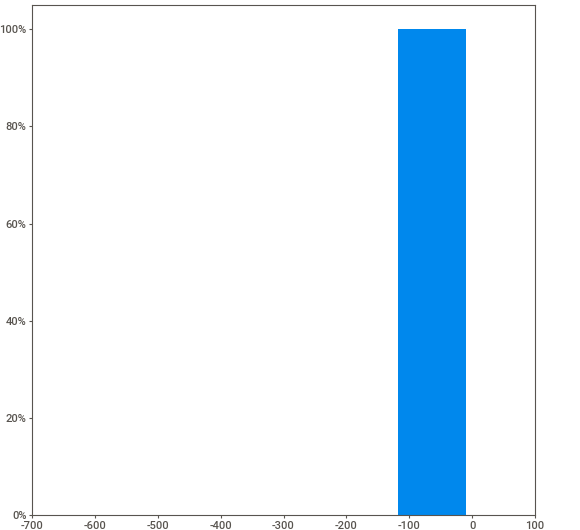
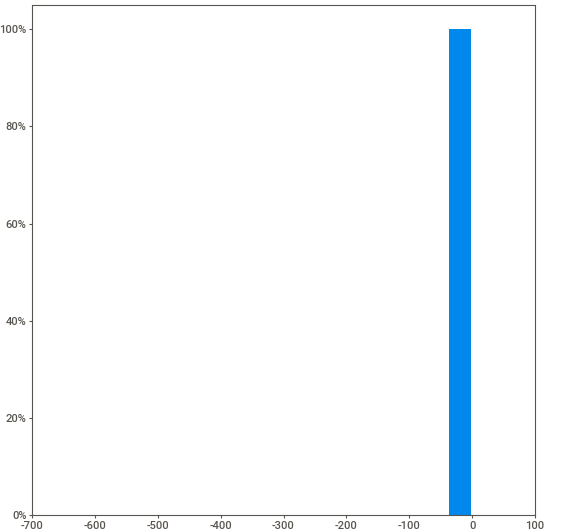
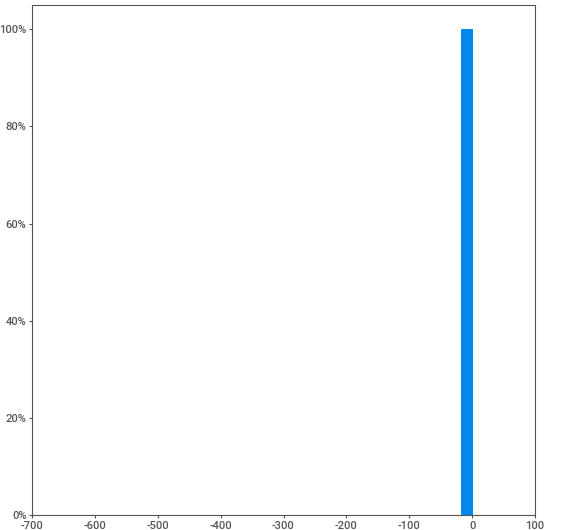
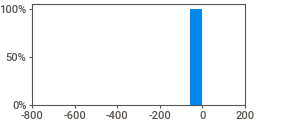
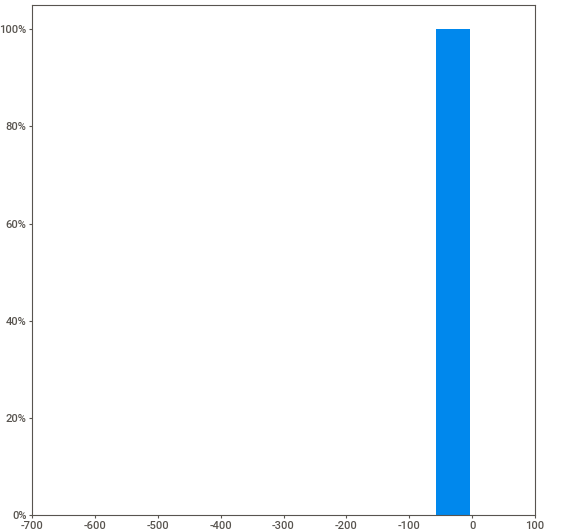
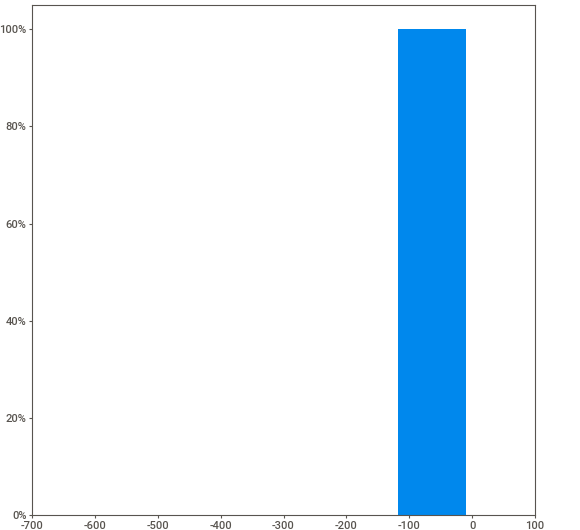
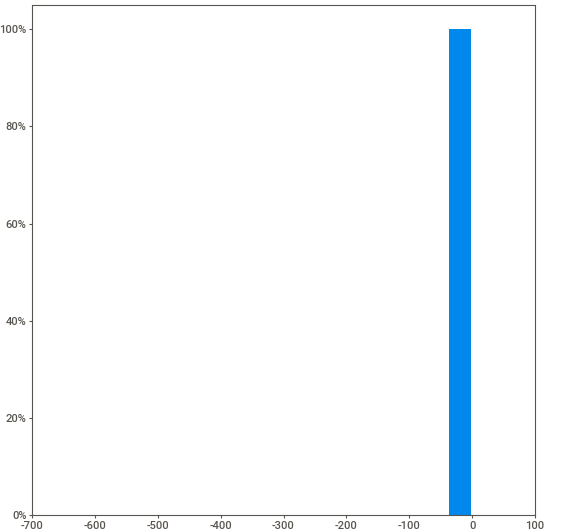
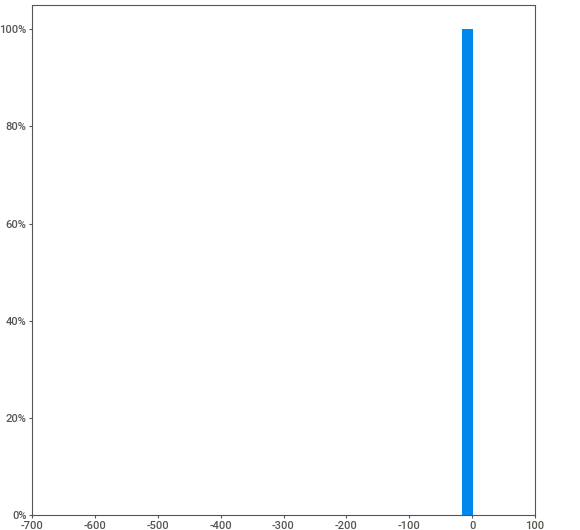
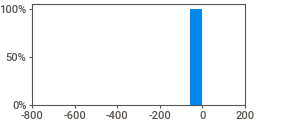
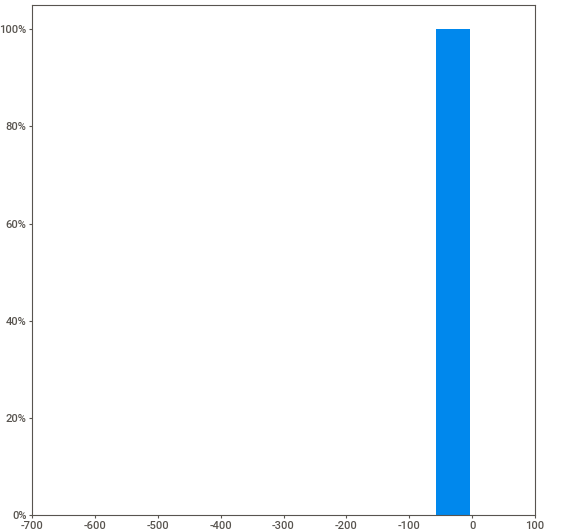
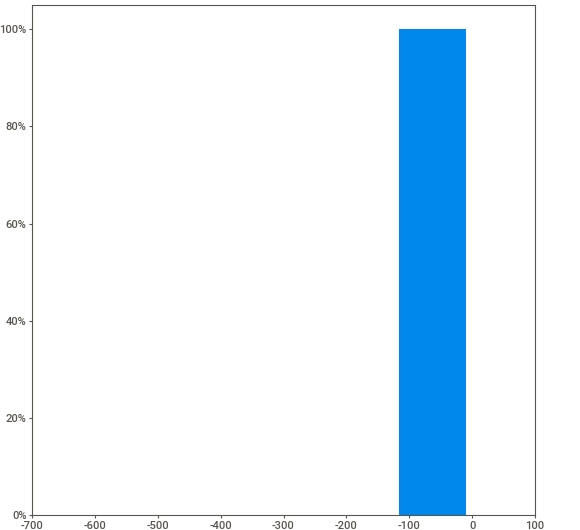
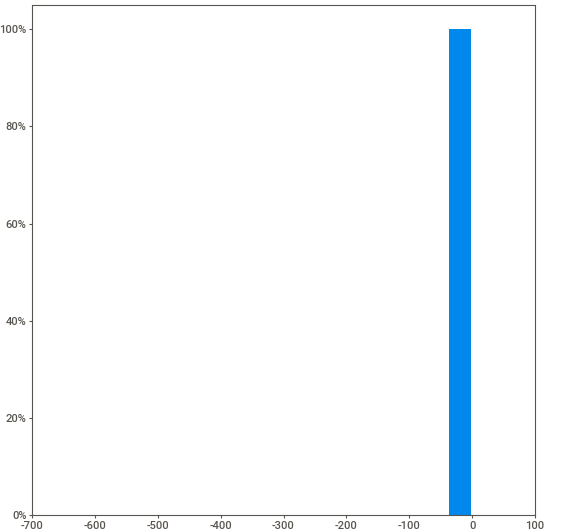
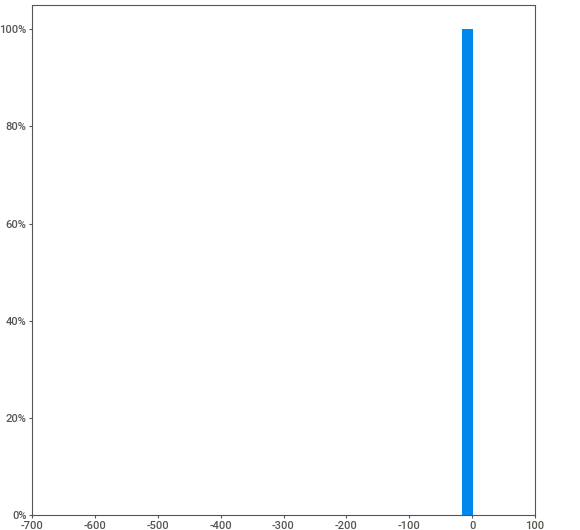
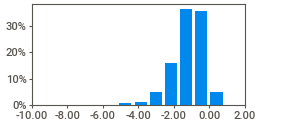
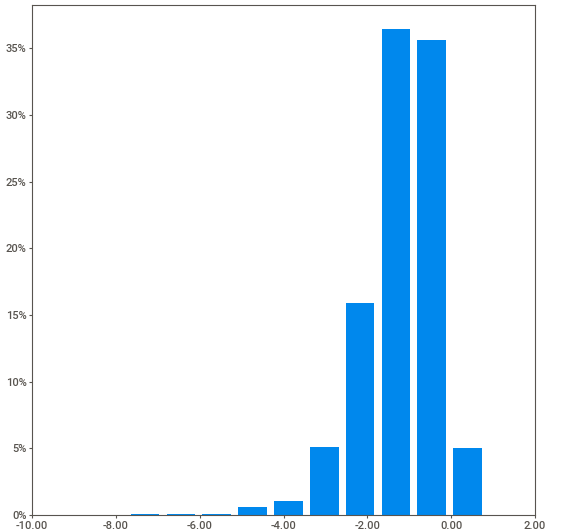
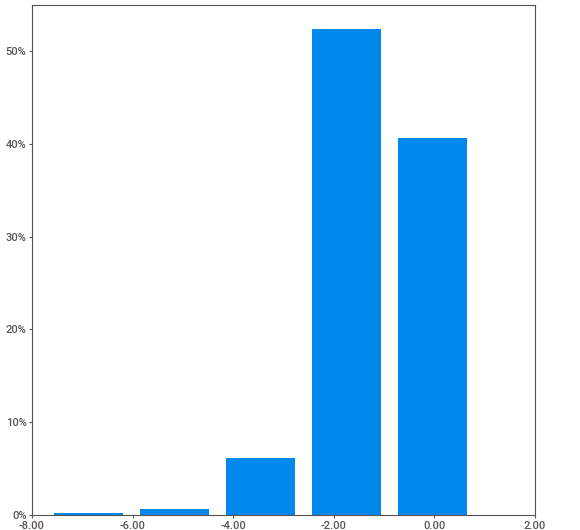
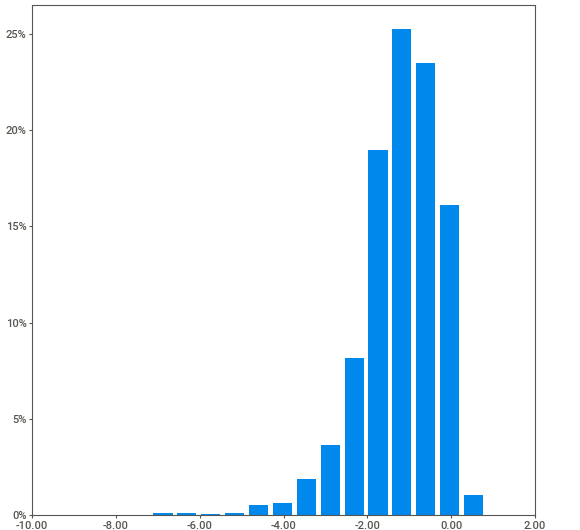
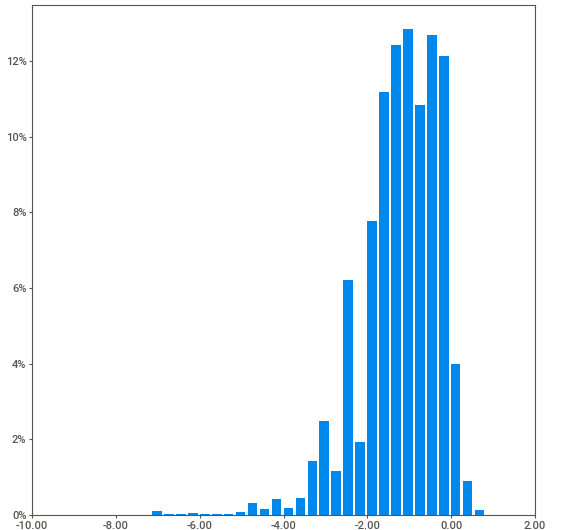
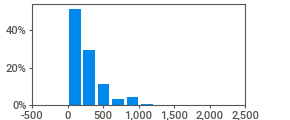
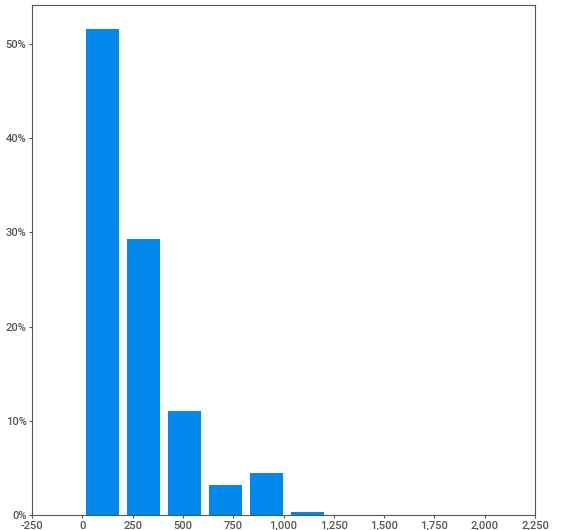
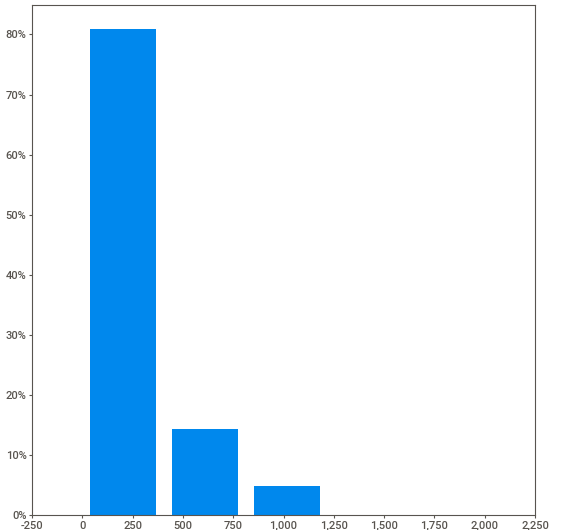
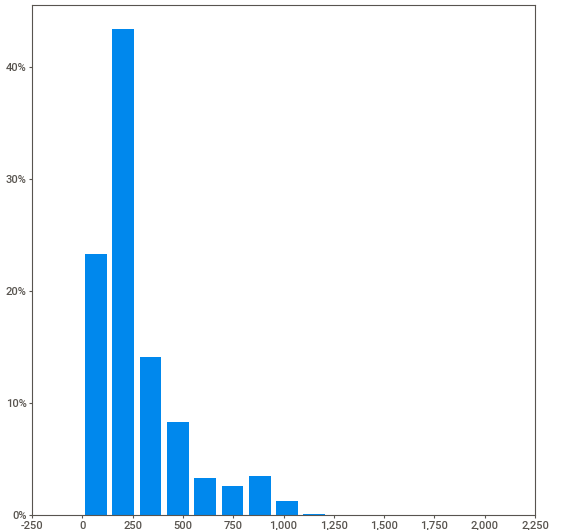
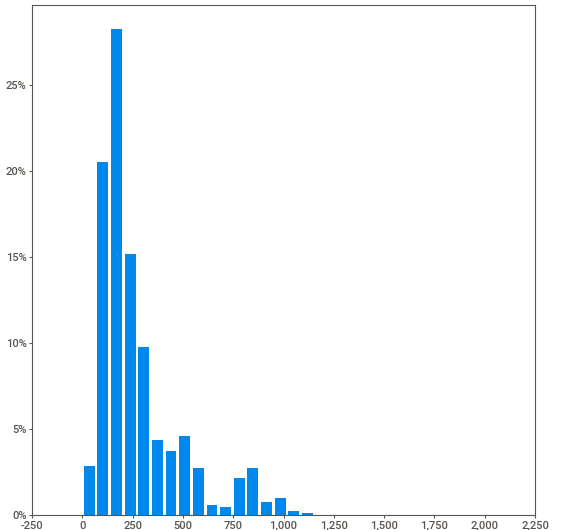
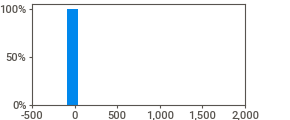
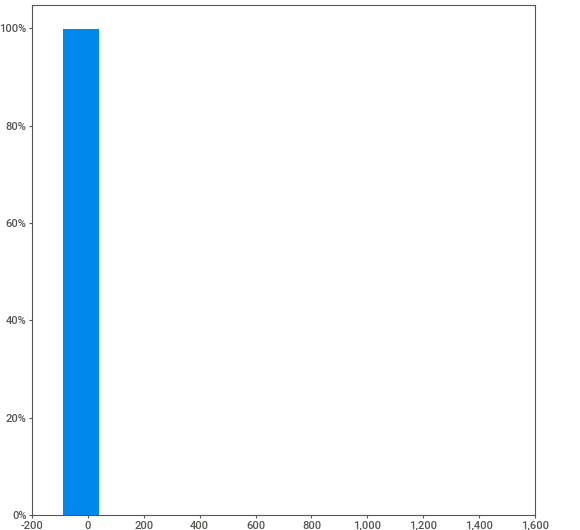
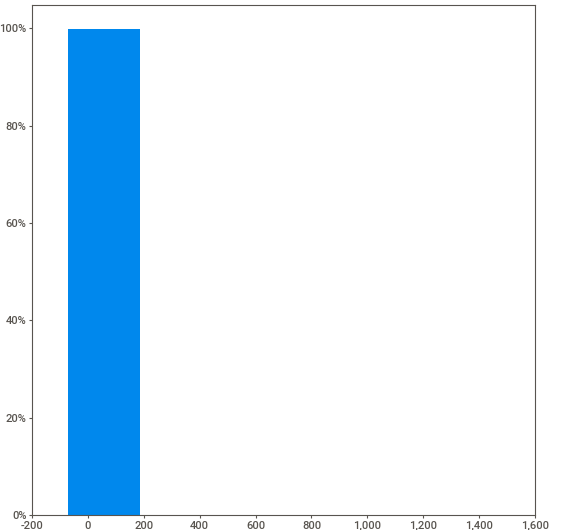
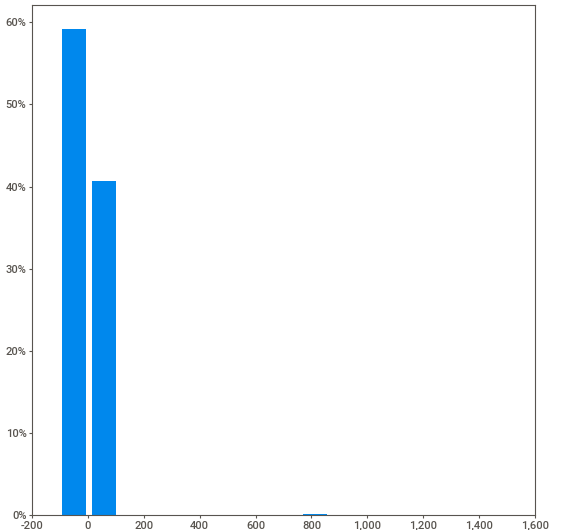
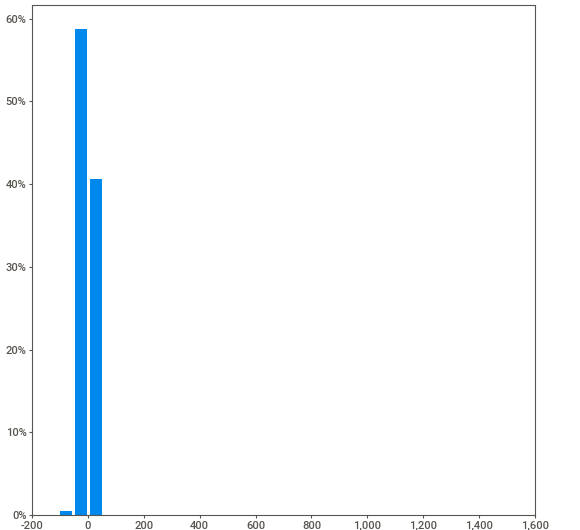
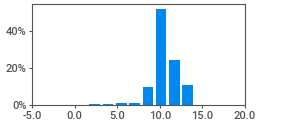
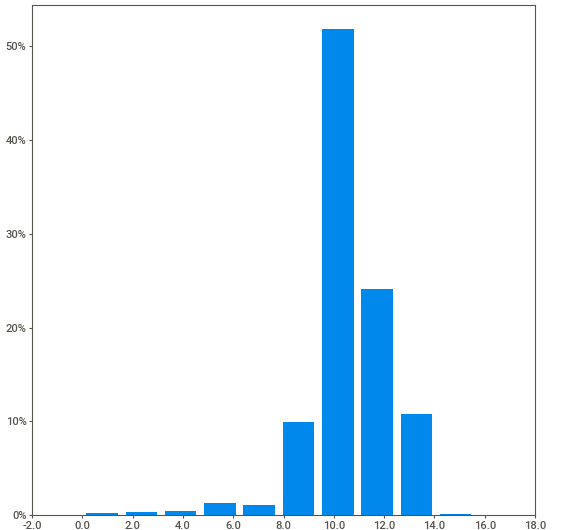
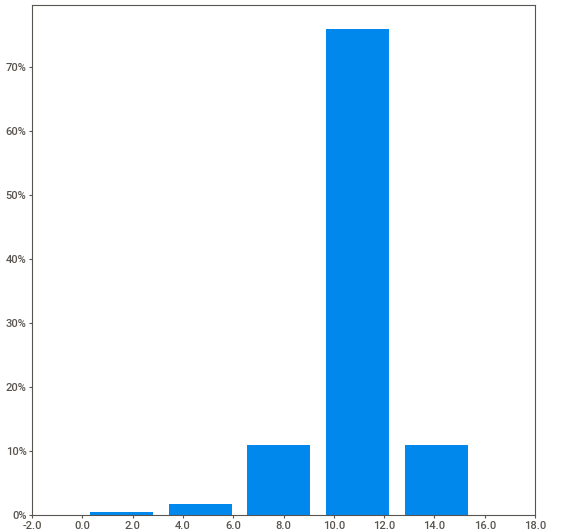
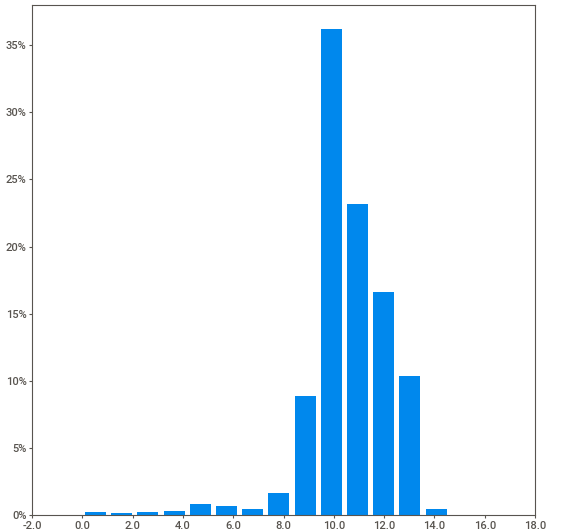
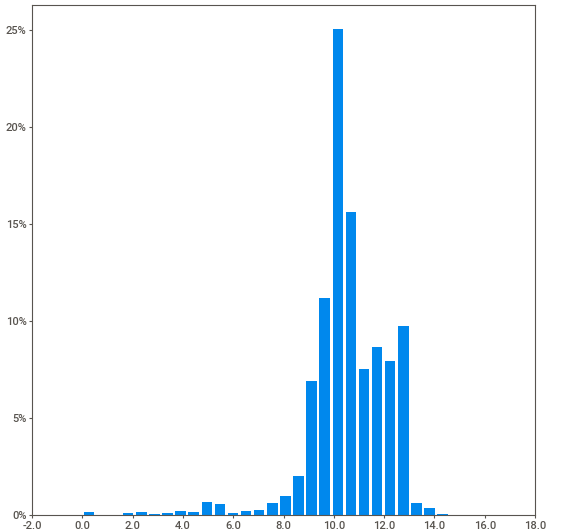
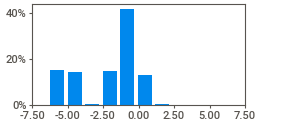
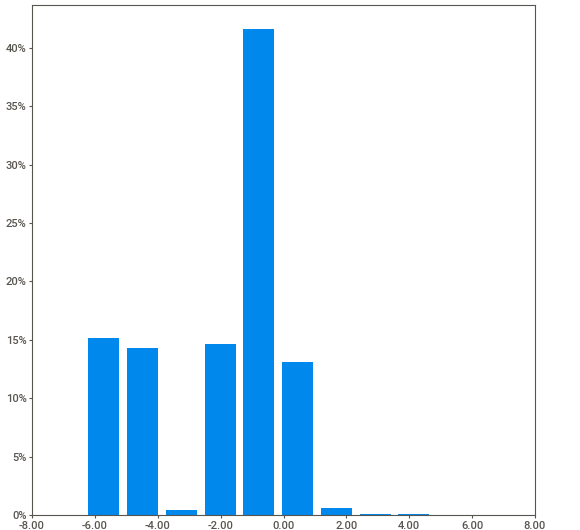
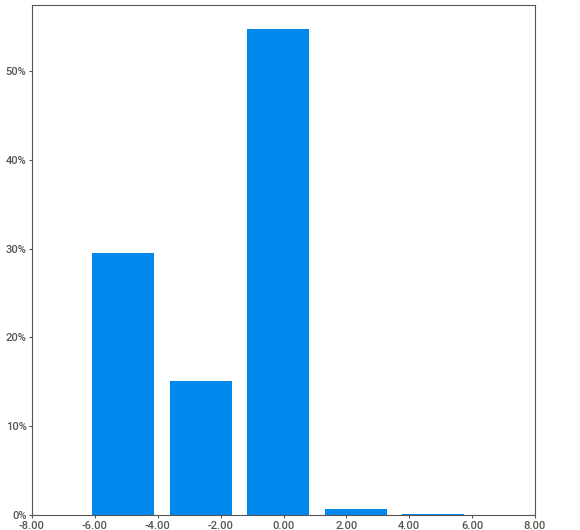
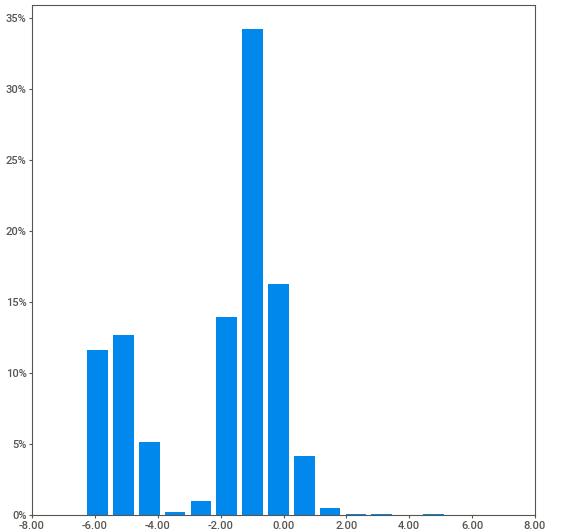
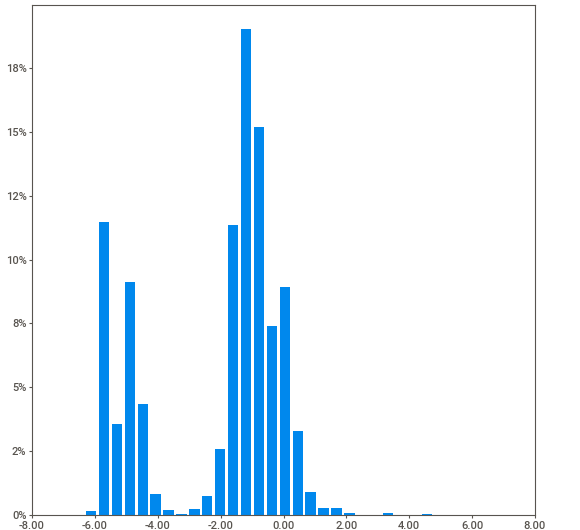
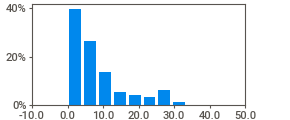
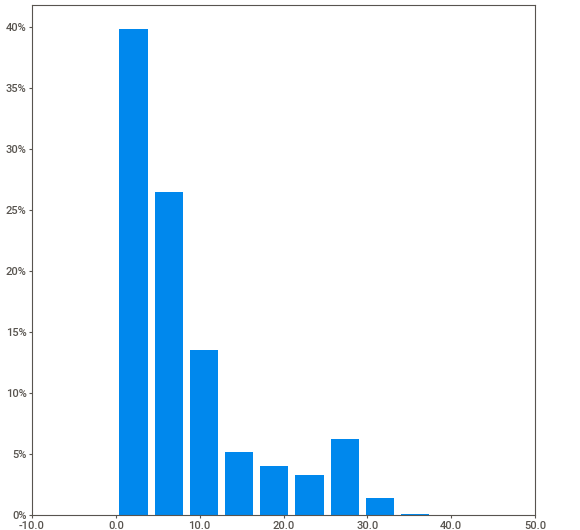
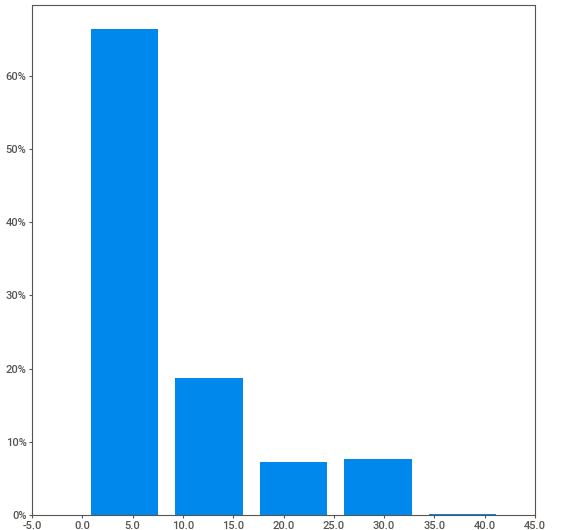
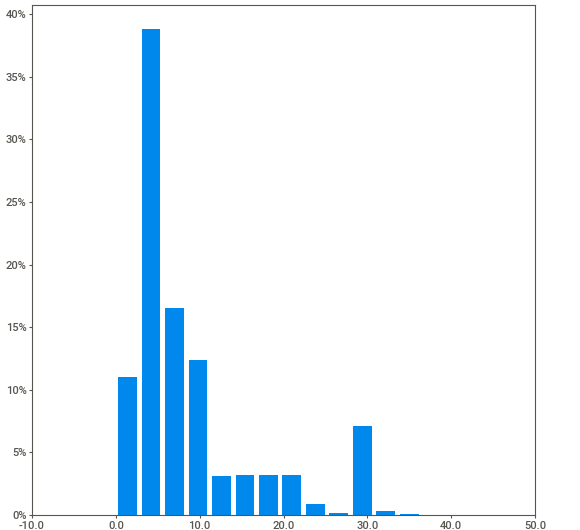
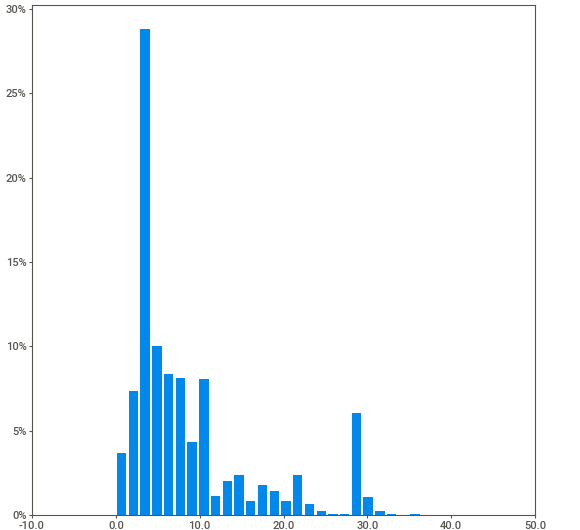
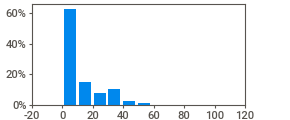
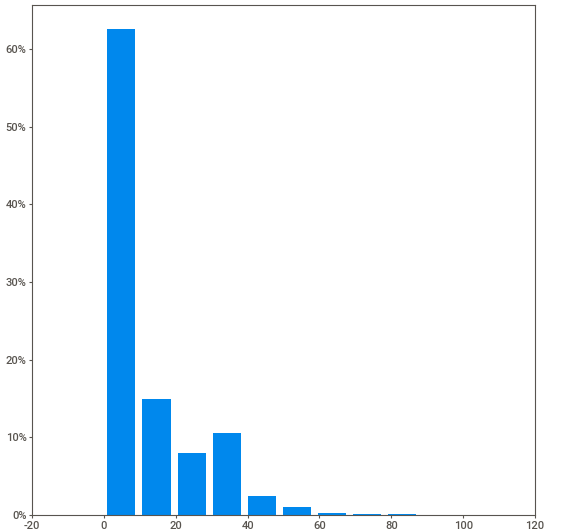
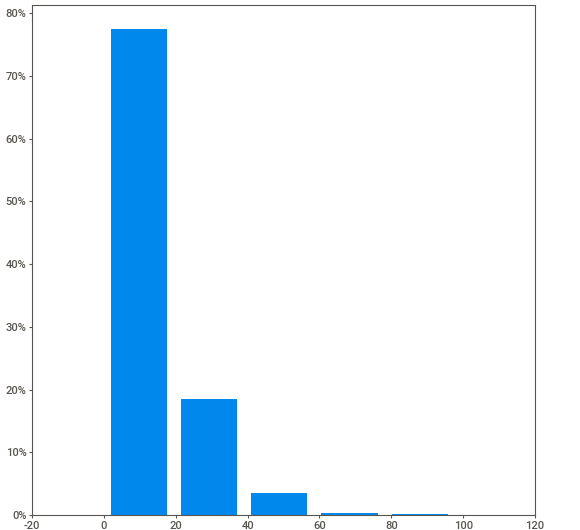
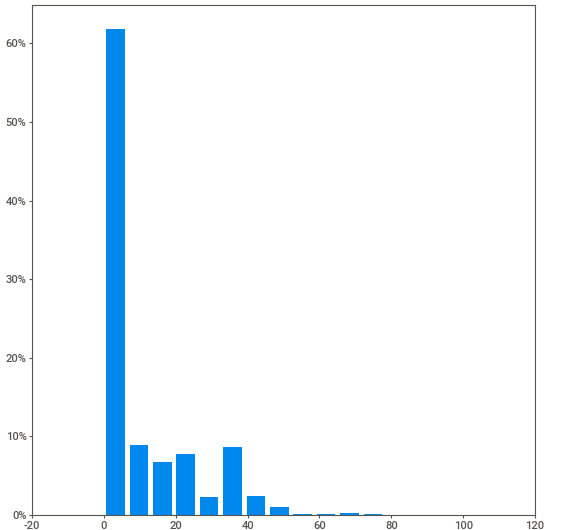
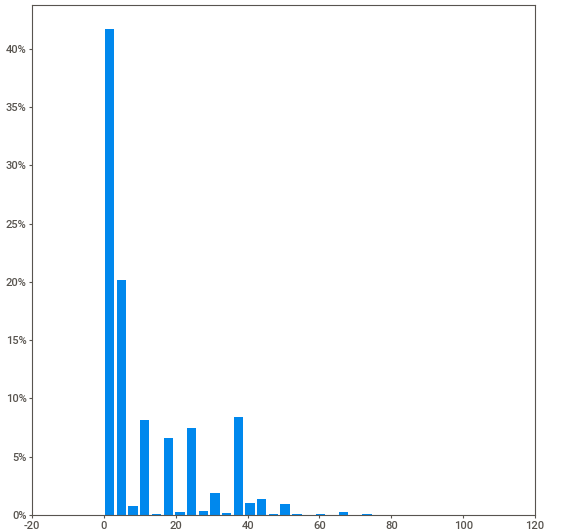
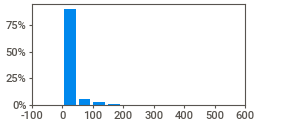
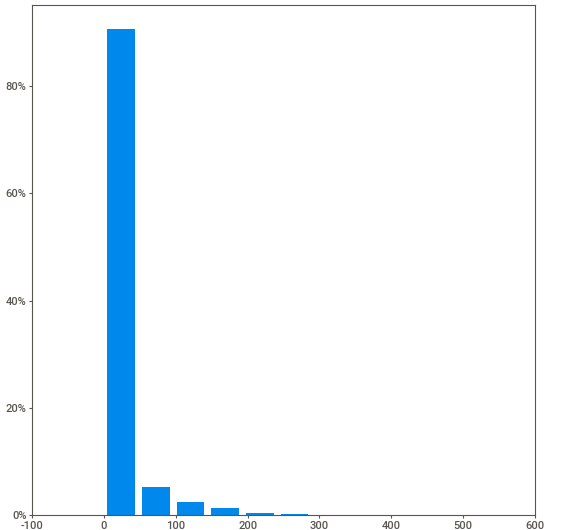
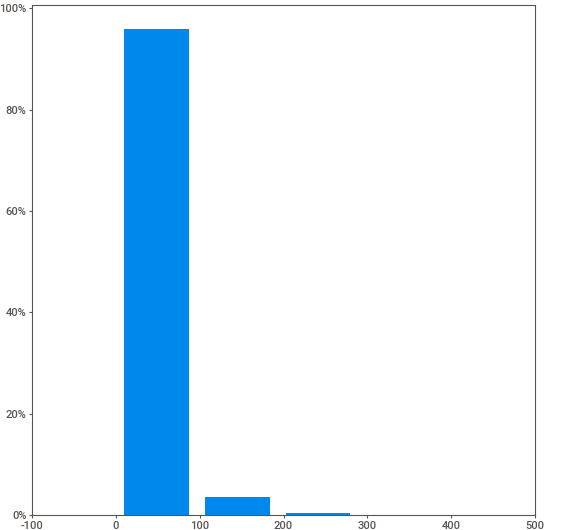
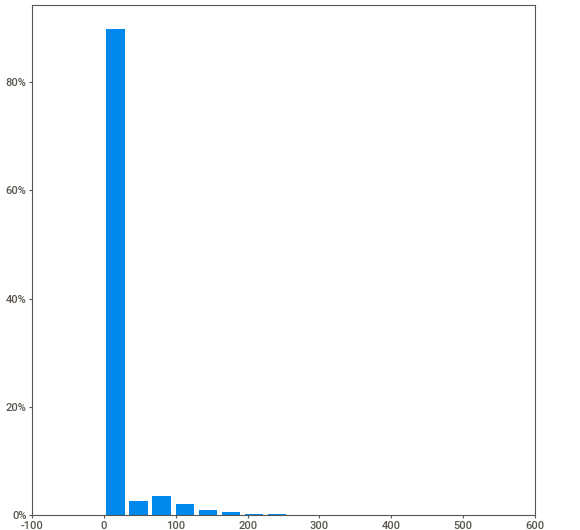
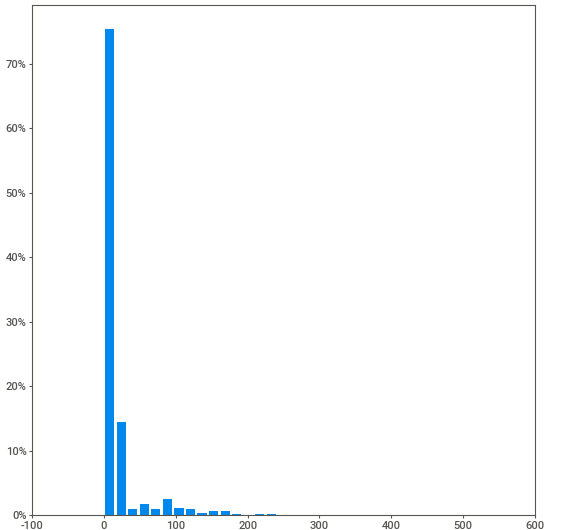
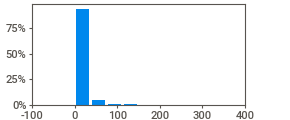
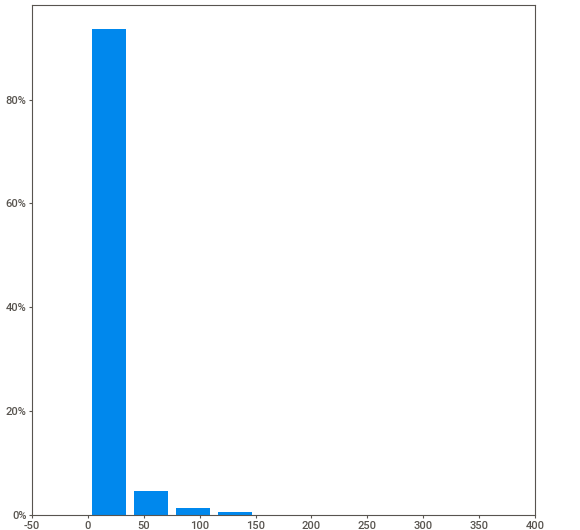
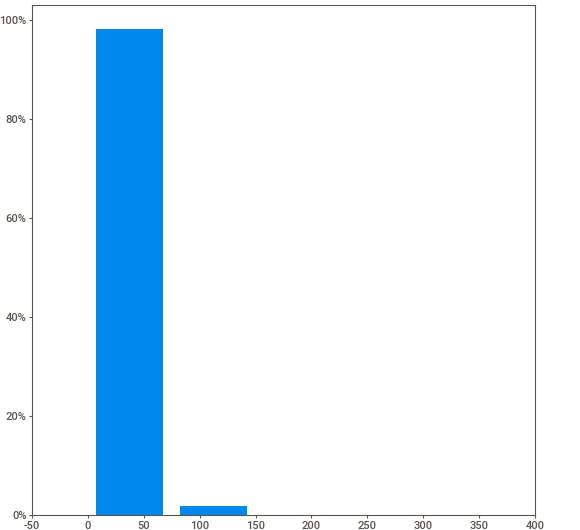
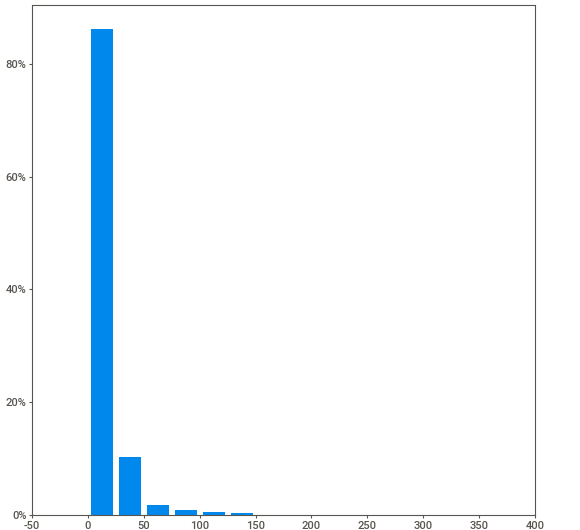
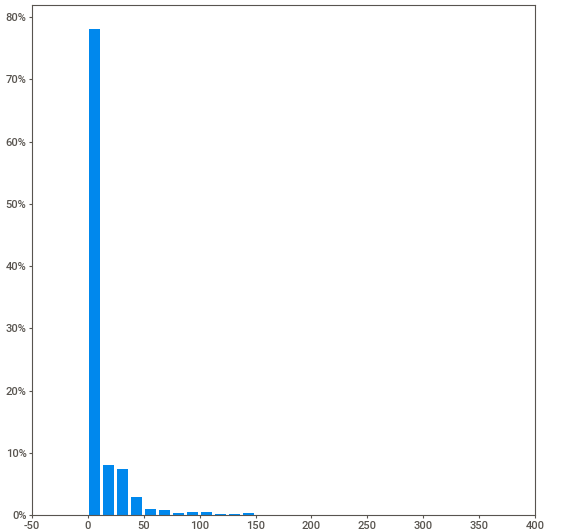
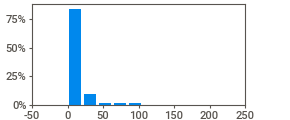
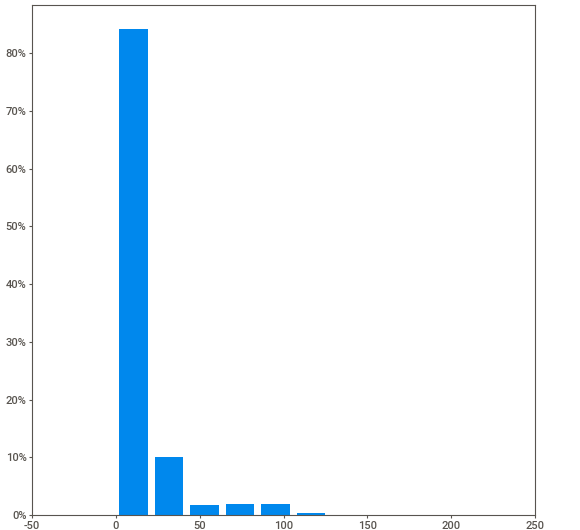
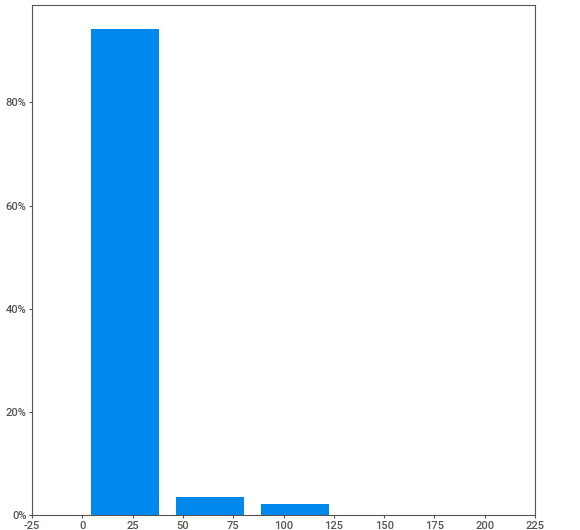
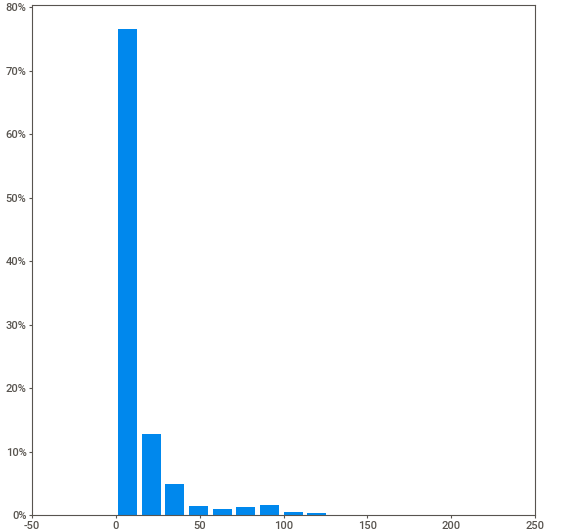
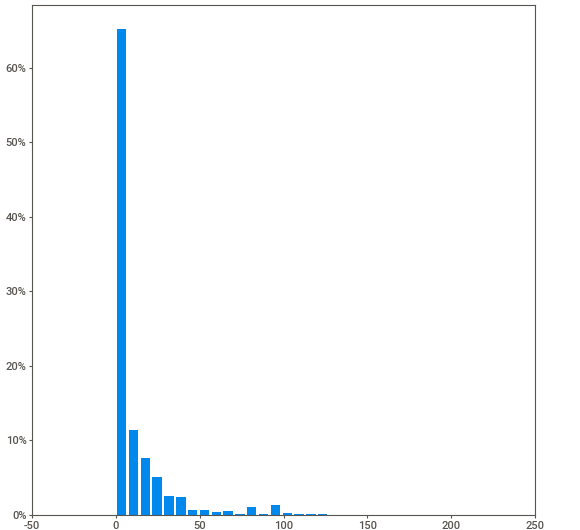
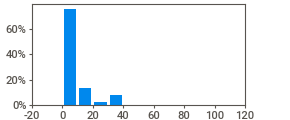
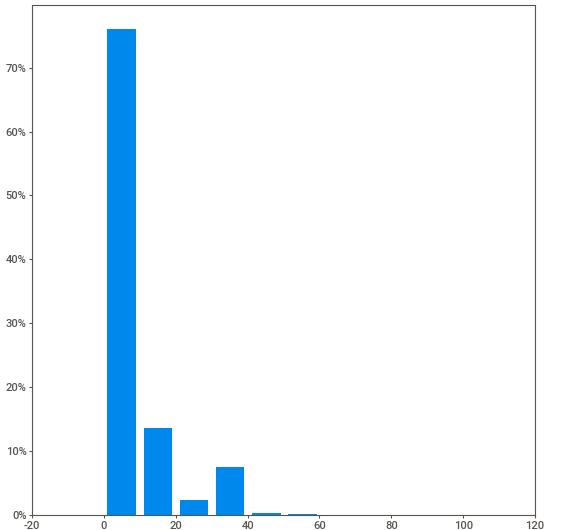
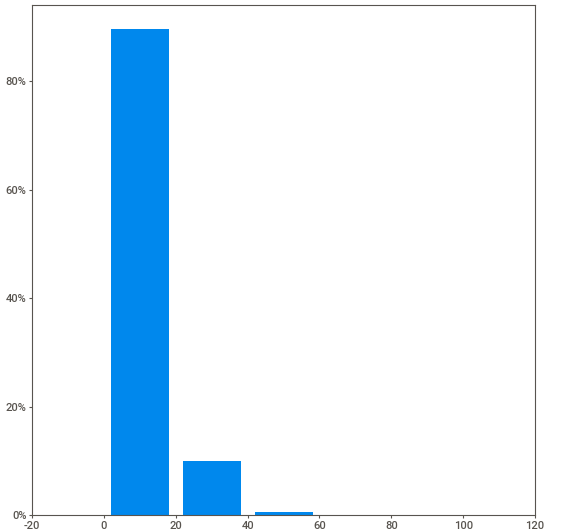
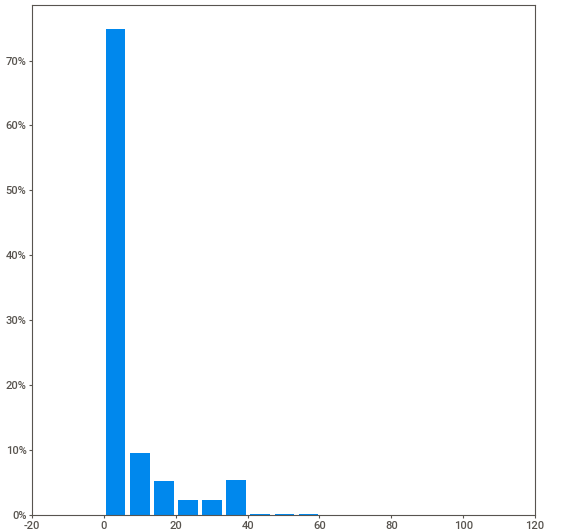
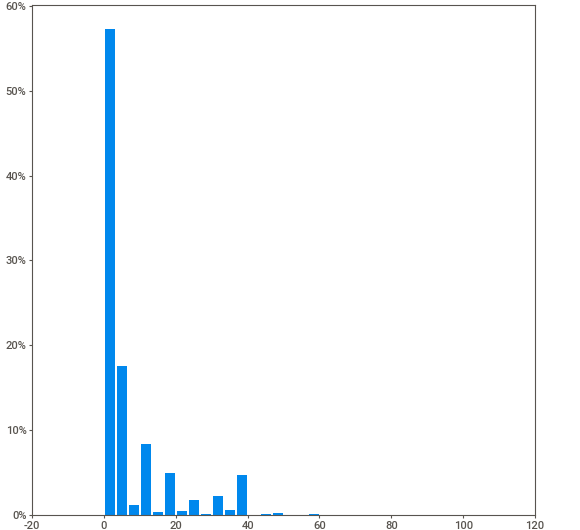
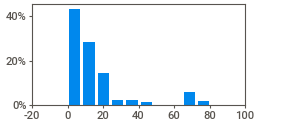
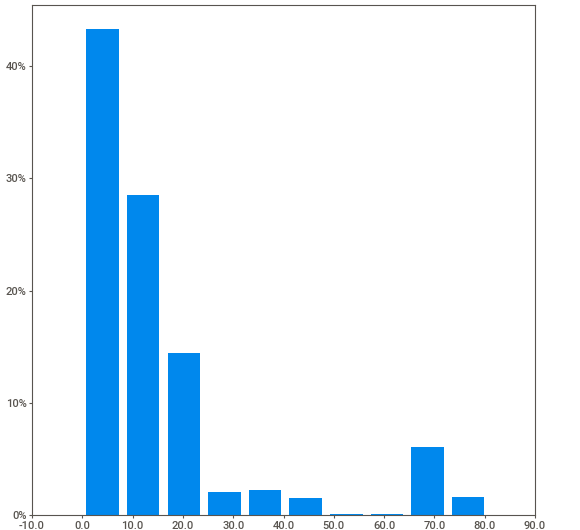
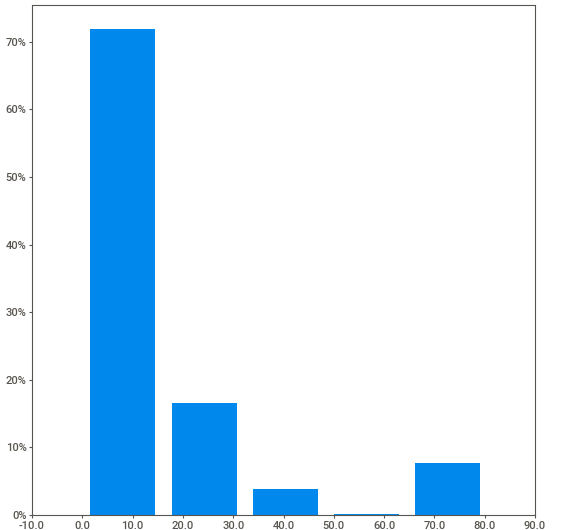
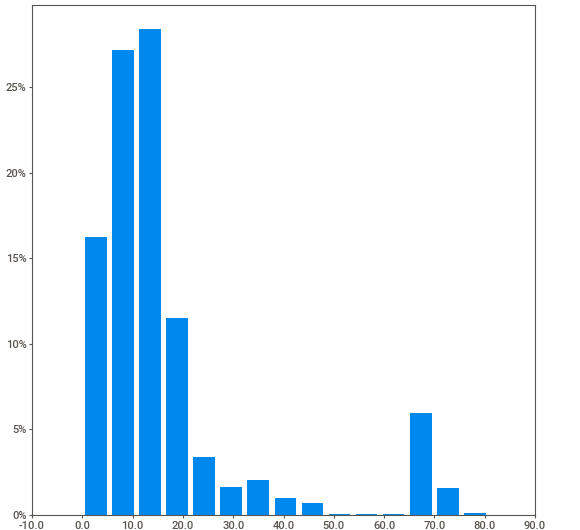
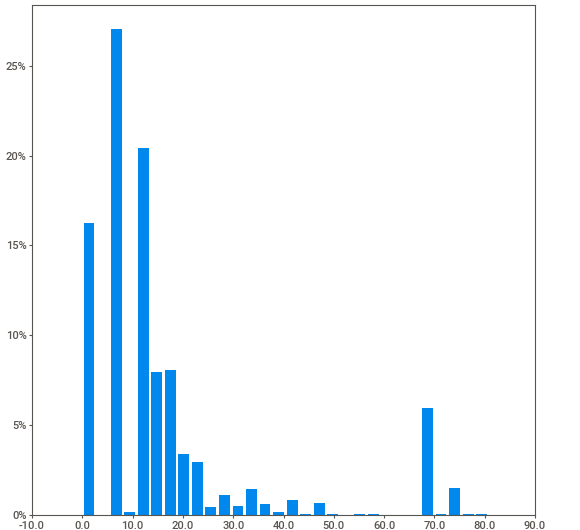
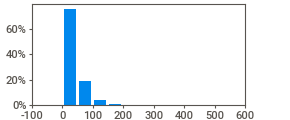
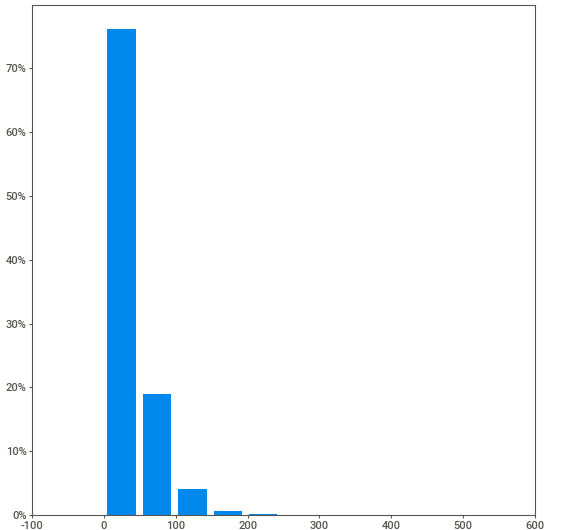
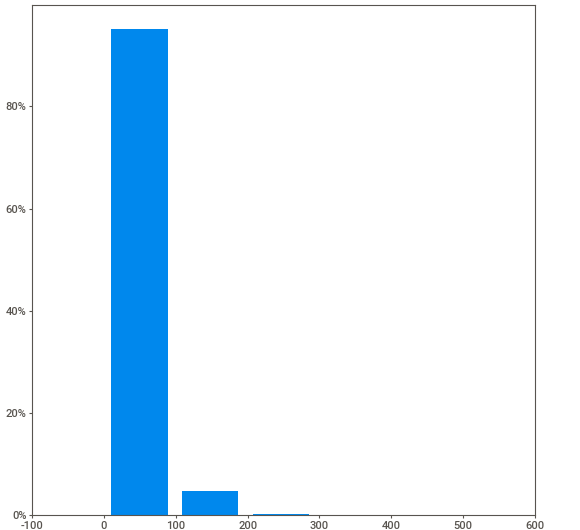
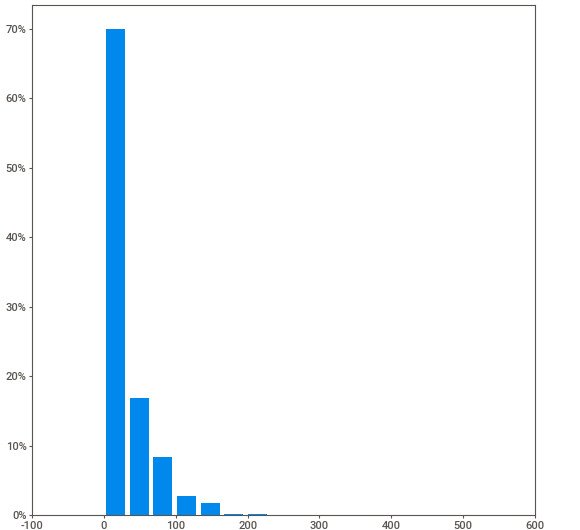
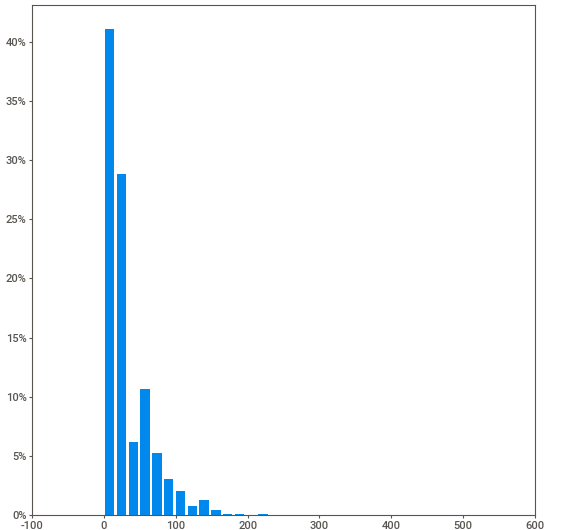
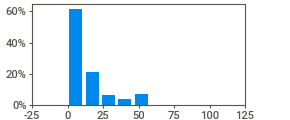
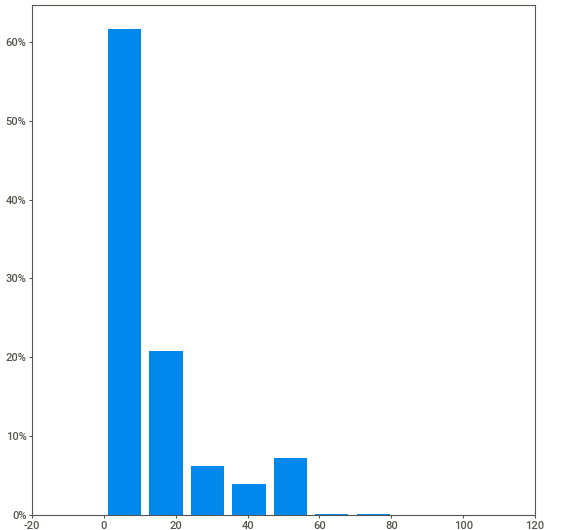
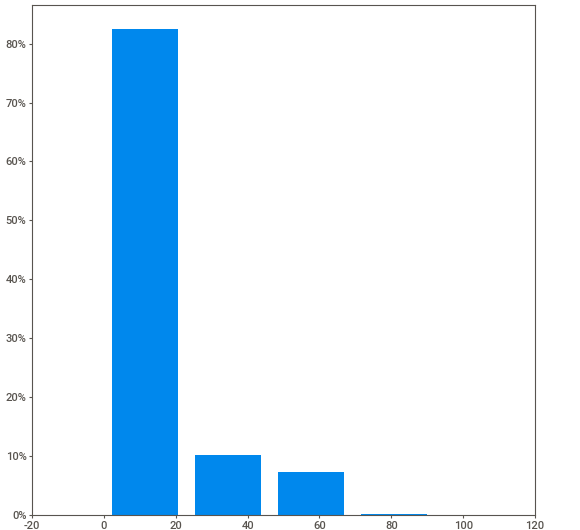
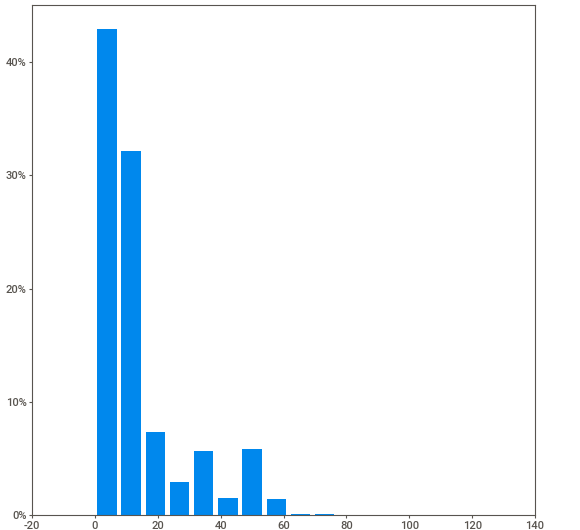
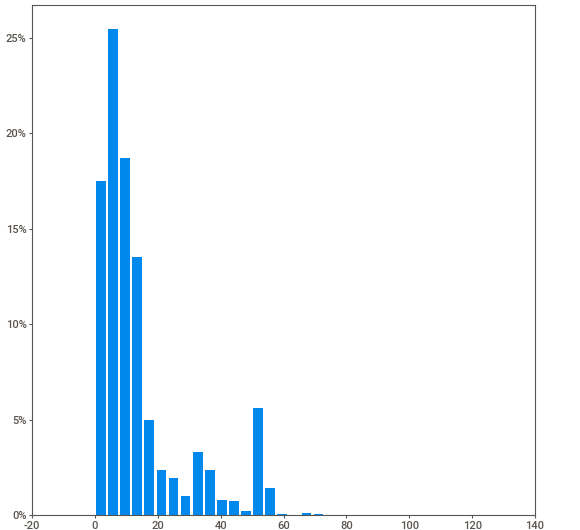
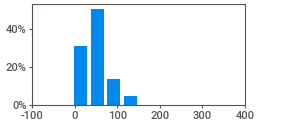
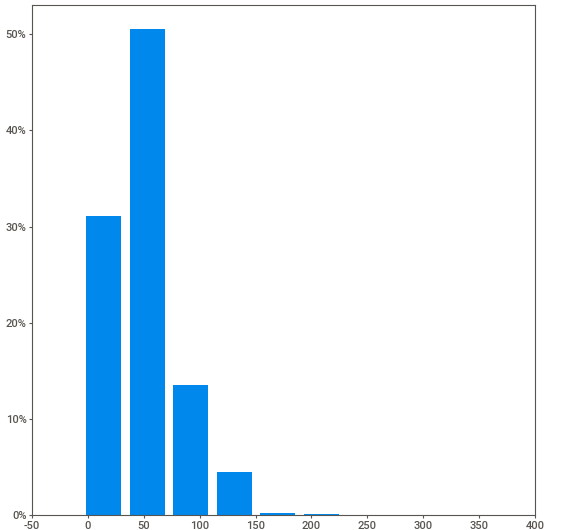
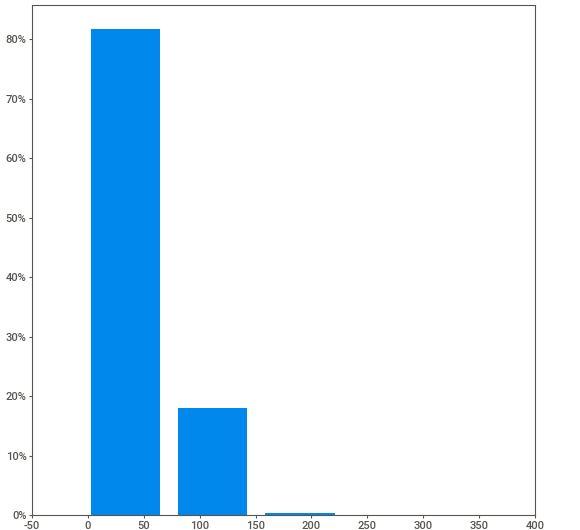
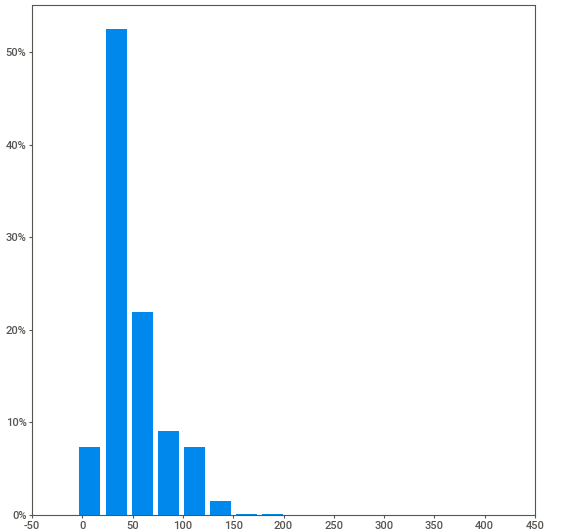
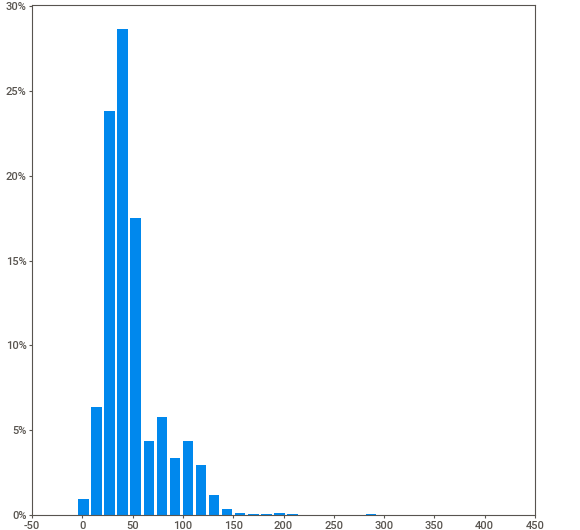
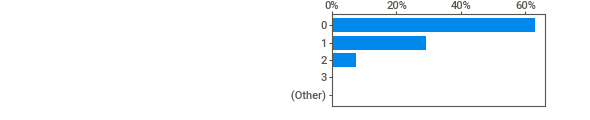
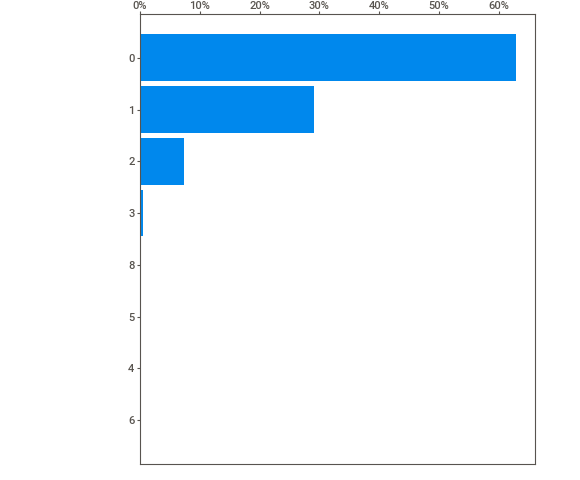
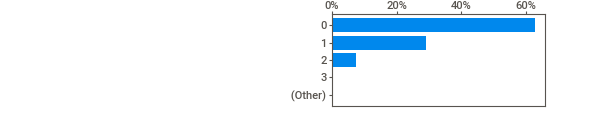
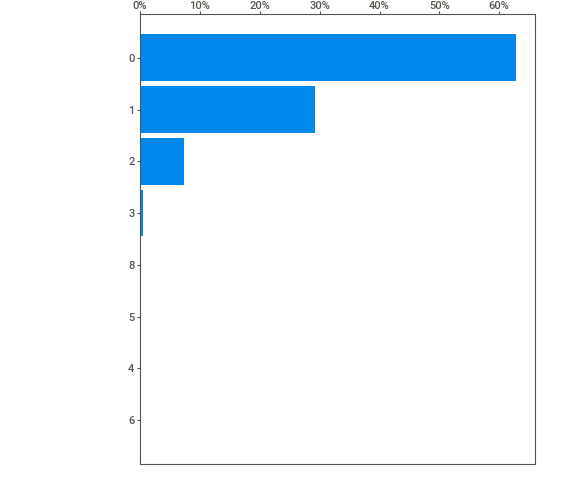
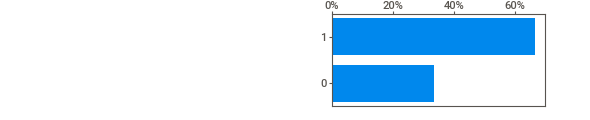
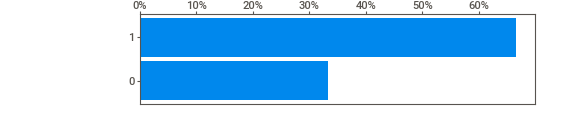
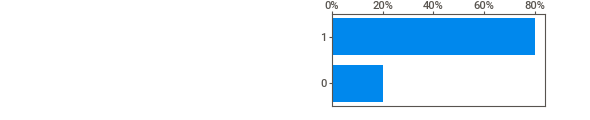
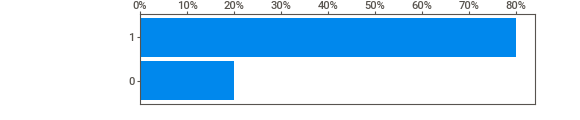
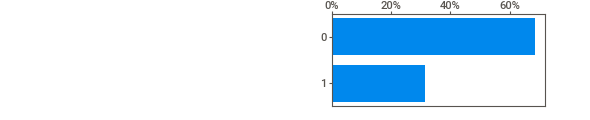
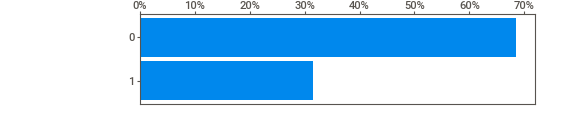
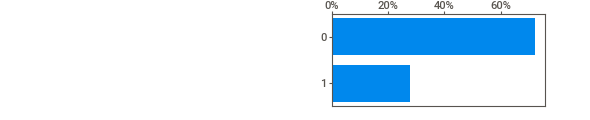
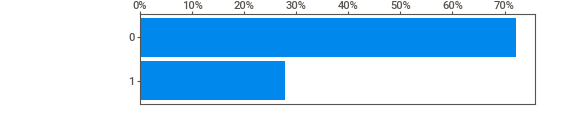
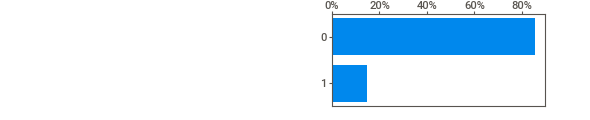
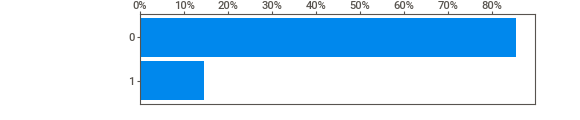
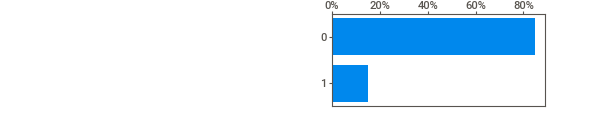
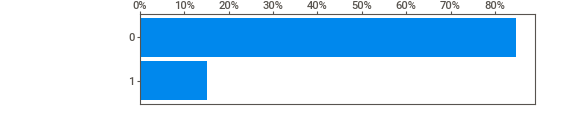
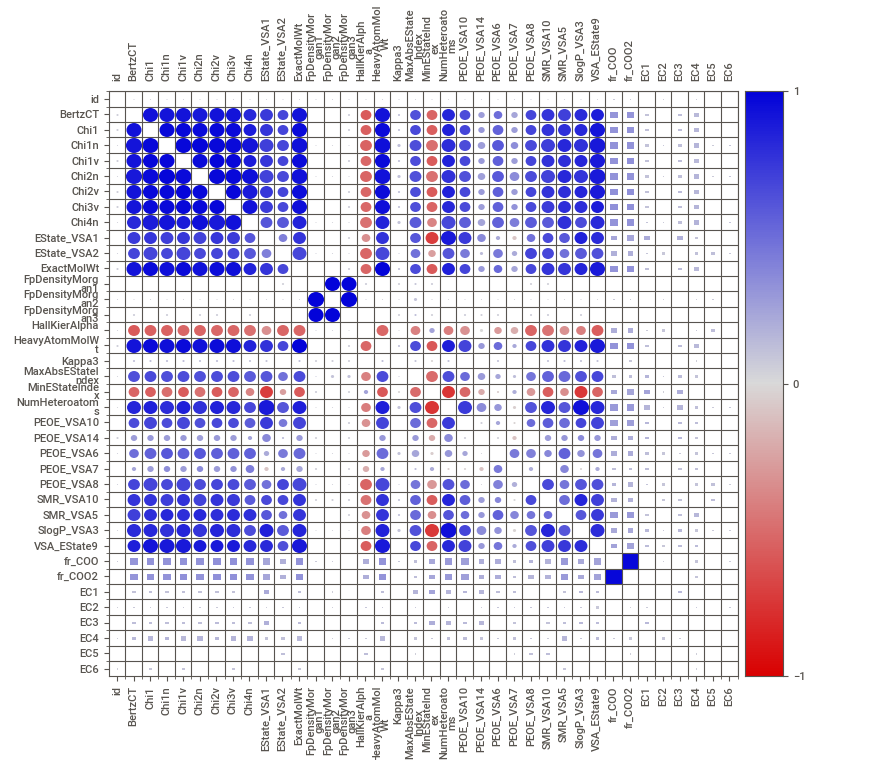
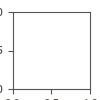

In [7]:
my_report.show_notebook(w="98%", h="full") # if working in Kaggle
